In [1]:
import pandas as pd

In [2]:
print("")

In [3]:
df = pd.read_csv("../../dataset/05_merged/final_latest_calls_fullcols.csv")
df.info()

df_copy = df.copy()

C:\Users\Asus\AppData\Local\Temp\ipykernel_22448\1263138397.py:1: DtypeWarning: Columns (0: cc_contractor_sentiment_start_score_cc, 1: cc_contractor_sentiment_end_score_cc) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../dataset/05_merged/final_latest_calls_fullcols.csv")


<class 'pandas.DataFrame'>
RangeIndex: 122082 entries, 0 to 122081
Columns: 122 entries, Co_Ref to Call_Year_cc
dtypes: float64(26), int64(10), object(4), str(82)
memory usage: 113.6+ MB


In [4]:
df = df[df['Prospect_Outcome'] != 'Open']

In [5]:
print(df['Prospect_Outcome'].unique())
len(df.columns)

<StringArray>
['Won', 'Churned']
Length: 2, dtype: str


122

In [6]:
print(len(df))

113894


In [7]:
null_percent = (df.isnull().sum() / len(df)) * 100
null_percent = null_percent.sort_values(ascending=False)

null_dict = null_percent.to_dict()
print(null_dict)

{'Churn_Category_renewal': 99.06931006023144, 'Complaint_Category_renewal': 97.82956081970954, 'cc_issues_within_questionnaire_cc': 97.2772929214884, 'cc_contractor_complained_cc': 97.24305055577993, 'cc_contractor_suggest_leave_cc': 97.24305055577993, 'cc_contractor_sentiment_cc': 97.24305055577993, 'cc_care_package_cc': 97.23953851827137, 'cc_care_package_discussed_cc': 97.23953851827137, 'cc_urgency_getting_on_site_cc': 97.23953851827137, 'cc_external_consultant_cc': 97.23953851827137, 'cc_agent_cross_sell_attempt_cc': 97.23953851827137, 'cc_customer_issues_concerns_cc': 97.23953851827137, 'cc_business_struggles_financial_hardship_cc': 97.23953851827137, 'cc_call_initiated_by_cc': 97.23953851827137, 'cc_dissatisfaction_time_to_complete_cc': 97.23427046200854, 'cc_platform_issues_cc': 97.23427046200854, 'cc_login_issues_cc': 97.23427046200854, 'cc_process_complexity_concerns_cc': 97.23427046200854, 'cc_questions_harder_than_expected_cc': 97.23427046200854, 'cc_dissatisfaction_support

In [8]:
null_percent = (df.isnull().sum() / len(df)) * 100
null_percent = null_percent.sort_values(ascending=False)

# filter > 75%
high_null_dict = null_percent[null_percent > 70].to_dict()

print(high_null_dict)

{'Churn_Category_renewal': 99.06931006023144, 'Complaint_Category_renewal': 97.82956081970954, 'cc_issues_within_questionnaire_cc': 97.2772929214884, 'cc_contractor_complained_cc': 97.24305055577993, 'cc_contractor_suggest_leave_cc': 97.24305055577993, 'cc_contractor_sentiment_cc': 97.24305055577993, 'cc_care_package_cc': 97.23953851827137, 'cc_care_package_discussed_cc': 97.23953851827137, 'cc_urgency_getting_on_site_cc': 97.23953851827137, 'cc_external_consultant_cc': 97.23953851827137, 'cc_agent_cross_sell_attempt_cc': 97.23953851827137, 'cc_customer_issues_concerns_cc': 97.23953851827137, 'cc_business_struggles_financial_hardship_cc': 97.23953851827137, 'cc_call_initiated_by_cc': 97.23953851827137, 'cc_dissatisfaction_time_to_complete_cc': 97.23427046200854, 'cc_platform_issues_cc': 97.23427046200854, 'cc_login_issues_cc': 97.23427046200854, 'cc_process_complexity_concerns_cc': 97.23427046200854, 'cc_questions_harder_than_expected_cc': 97.23427046200854, 'cc_dissatisfaction_support

In [9]:
cols_drop_95 = [col for col, val in high_null_dict.items() if val > 95]
df = df.drop(columns=cols_drop_95)

In [10]:
import numpy as np

# ── 1. Explicit Switching Intent ─────────────────────────────
col = 'Explicit_Switching_Intent_renewal'
df[col] = (
    df[col]
    .replace(np.nan, 'Unknown')   # handle NULL first
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        'yes': 'Yes',
        'no': 'No',
        'unknown': 'Unknown'
    })
    .fillna('Unknown')
)


# ── 2. Discount Offered ─────────────────────────────────────
col = 'Discount_Offered_renewal'
df[col] = (
    df[col]
    .replace(np.nan, 'Unknown')
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        'yes': 'Yes',
        'no': 'No',
        'unknown': 'Unknown'
    })
    .fillna('Unknown')
)


# ── 3. Customer Response ────────────────────────────────────
col = 'Customer_Response_renewal'
df[col] = (
    df[col]
    .replace(np.nan, 'Unknown')
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        'positive': 'Positive',
        'negative': 'Negative',
        'neutral': 'Neutral',
        'unknown': 'Unknown'
    })
    .fillna('Unknown')
)


# ── 4. Desire To Cancel ─────────────────────────────────────
col = 'Desire_To_Cancel_renewal'
df[col] = (
    df[col]
    .replace(np.nan, 'Unknown')
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        'renewed': 'Renew',
        'renew': 'Renew',
        'desired to cancel': 'Cancel',
        'unknown': 'Unknown'
    })
    .fillna('Unknown')
)



import numpy as np

# Generic cleaner + encoder
def binary_encode(col, mapping):
    return (
        df[col]
        .replace(np.nan, 'Unknown')
        .astype(str)
        .str.strip()
        .str.lower()
        .map(mapping)
        .fillna(0)   # Unknown → 0 (no signal)
    )


# ── 1. Explicit Switching Intent ─────────────────────────────
df['Explicit_Switching_Intent_flag'] = binary_encode(
    'Explicit_Switching_Intent_renewal',
    {
        'yes': 1,
        'no': 0,
        'unknown': 0
    }
)


# ── 2. Discount Offered ─────────────────────────────────────
df['Discount_Offered_flag'] = binary_encode(
    'Discount_Offered_renewal',
    {
        'yes': 1,
        'no': 0,
        'unknown': 0
    }
)


# ── 3. Customer Response (convert to NEGATIVE signal) ────────
df['Customer_Response_flag'] = binary_encode(
    'Customer_Response_renewal',
    {
        'negative': 1,   # churn signal
        'positive': 0,
        'neutral': 0,
        'unknown': 0
    }
)


# ── 4. Desire To Cancel ─────────────────────────────────────
df['cancel_flag'] = binary_encode(
    'Desire_To_Cancel_renewal',
    {
        'desired to cancel': 1,
        'cancel': 1,
        'renew': 0,
        'renewed': 0,
        'unknown': 0
    }
)

df = df.drop(columns=[
    'Explicit_Switching_Intent_renewal',
    'Discount_Offered_renewal',
    'Customer_Response_renewal',
    'Desire_To_Cancel_renewal'
])

In [11]:
print(df['cancel_flag'].value_counts())

cancel_flag
0    112322
1      1572
Name: count, dtype: int64


In [12]:
important_sparse_cols = [
    col for col, val in high_null_dict.items()
    if 80 < val <= 95
]

print(important_sparse_cols)

['Agent_Response_Category_renewal', 'Customer_Renewal_Response_Category_renewal', 'Agent_Renewal_Pitch_Category_renewal', 'Serious_Complaint_renewal', 'Other_Complaint_renewal', 'Competitor_Benefits_Mentioned_renewal', 'Membership_Renewal_Decision_renewal', 'Renewal_Impact_Due_to_Price_Increase_renewal', 'Discount_or_Waiver_Requested_renewal', 'Discussion_on_Price_Increase_renewal', 'Agent_Renewal_Initiation_renewal', 'Agent_Flagged_Membership_Status_Alert_renewal', 'Call_Reschedule_Request_renewal', 'Price_Switching_Mentioned_renewal', 'Mentioned_Competitors_renewal', 'Explicit_Switching_Intent_renewal', 'Explicit_Competitor_Mention_renewal', 'Price_Range_Mentioned_renewal', 'Monetary_Price_Increase_Mentioned_renewal', 'Topic_Introduced_By_renewal', 'Customer_Asked_For_Justification_renewal', 'Customer_Response_renewal', 'Desire_To_Cancel_renewal', 'Discount_Offered_renewal', 'Percentage_Price_Increase_Mentioned_renewal', 'Analysed_Call_renewal']


In [13]:
# Drop known useless columns
drop_cols = [
    # 'Co_Ref',
    'Call_ID_renewal',
    'Contact_ID_cc',
    'Call_Date_renewal',
    'Prospect_Renewal_Date'
]

df = df.drop(columns=[col for col in drop_cols if col in df.columns])

In [14]:
len(df.columns)
print(df.columns)

Index(['Co_Ref', 'Renewal_Month', 'Discount_Amount', 'Sustainability_Score',
       'Total_Renewal_Score_New', 'Last_Years_Price', 'Auto_Renewal_Score',
       'Status_Scores', 'Anchoring_Score', 'Tenure_Scores',
       'Proforma_Auto_Renewal', 'Proforma_World_Pay_Token', 'Proforma_Date',
       'Current_Anchorings', 'Current_Anchor_List', 'Payment_Timeframe',
       'Registration_Date', 'Proforma_Account_Stage', 'Proforma_Audit_Status',
       'Current_Auto_Renewal_Flag', 'Current_World_Pay_Token',
       'Renewal_Score_At_Release', 'Proforma_Membership_Status',
       'Proforma_Approved_Lists', 'Tenure_Years', 'Band', 'Closed_Date',
       'Prospect_Status', 'Starting_Net', 'Starting_Vat', 'Starting_Gross',
       'Starting_Membership_Net', 'Starting_Package_Net', 'Starting_PQQ_Net',
       'Gross', 'Membership_Net', 'Package_Net', 'PQQNet', 'Total_Net_Paid',
       'Prospect_Outcome', 'Payment_Method', 'Amount', 'Total_Amount',
       'Connection_Group', 'Tenure_Group', '#_of_Connec

In [15]:
drop_cols += [
    'Starting_Vat',
    'Starting_Gross',
    'Starting_Membership_Net',
    'Starting_Package_Net',
    'Starting_PQQ_Net',
    'Starting_Net',
    'Gross',
    'Membership_Net',
    'Package_Net',
    'PQQNet',
    'Amount'
]

df = df.drop(columns = drop_cols , errors='ignore')

In [16]:
# keep_cat = [
#     'Payment_Method',
#     'Band',
#     'Connection_Group',
#     'Tenure_Group',
#     'Anchor_Group'
# ]

len(df.columns)

print(df.columns)

Index(['Co_Ref', 'Renewal_Month', 'Discount_Amount', 'Sustainability_Score',
       'Total_Renewal_Score_New', 'Last_Years_Price', 'Auto_Renewal_Score',
       'Status_Scores', 'Anchoring_Score', 'Tenure_Scores',
       'Proforma_Auto_Renewal', 'Proforma_World_Pay_Token', 'Proforma_Date',
       'Current_Anchorings', 'Current_Anchor_List', 'Payment_Timeframe',
       'Registration_Date', 'Proforma_Account_Stage', 'Proforma_Audit_Status',
       'Current_Auto_Renewal_Flag', 'Current_World_Pay_Token',
       'Renewal_Score_At_Release', 'Proforma_Membership_Status',
       'Proforma_Approved_Lists', 'Tenure_Years', 'Band', 'Closed_Date',
       'Prospect_Status', 'Total_Net_Paid', 'Prospect_Outcome',
       'Payment_Method', 'Total_Amount', 'Connection_Group', 'Tenure_Group',
       '#_of_Connection', 'Last_Renewal', 'Last_Band', 'Last_Total_Net_Paid',
       'Last_Connections', 'Anchor_Group', 'Renewal_Year', 'DateTime_Out',
       'Prev_Renewal_Date', 'Call_Direction_renewal',
       'A

In [17]:
df['target'] = df['Prospect_Outcome'].map({
    'Won': 0,
    'Churned': 1
})

df = df.drop(columns=['Prospect_Outcome'])

In [18]:
drop_cols = [
    'Call_Number_renewal'
]

In [19]:
# Convert to datetime
df['Closed_Date'] = pd.to_datetime(df['Closed_Date'], errors='coerce')
df['Registration_Date'] = pd.to_datetime(df['Registration_Date'], errors='coerce')

# Create feature
df['days_since_registration'] = (
    df['Closed_Date'] - df['Registration_Date']
).dt.days

C:\Users\Asus\AppData\Local\Temp\ipykernel_22448\3293522358.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Closed_Date'] = pd.to_datetime(df['Closed_Date'], errors='coerce')
C:\Users\Asus\AppData\Local\Temp\ipykernel_22448\3293522358.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Registration_Date'] = pd.to_datetime(df['Registration_Date'], errors='coerce')


In [20]:
date_cols = [
    'Proforma_Date',
    'Registration_Date',
    'Closed_Date',
    'Last_Renewal',
    'Prev_Renewal_Date',
    'DateTime_Out',
    # 'Payment_Method',
]
df = df.drop(columns=date_cols)

In [21]:
print(len(df.columns))

print(df.columns)


68
Index(['Co_Ref', 'Renewal_Month', 'Discount_Amount', 'Sustainability_Score',
       'Total_Renewal_Score_New', 'Last_Years_Price', 'Auto_Renewal_Score',
       'Status_Scores', 'Anchoring_Score', 'Tenure_Scores',
       'Proforma_Auto_Renewal', 'Proforma_World_Pay_Token',
       'Current_Anchorings', 'Current_Anchor_List', 'Payment_Timeframe',
       'Proforma_Account_Stage', 'Proforma_Audit_Status',
       'Current_Auto_Renewal_Flag', 'Current_World_Pay_Token',
       'Renewal_Score_At_Release', 'Proforma_Membership_Status',
       'Proforma_Approved_Lists', 'Tenure_Years', 'Band', 'Prospect_Status',
       'Total_Net_Paid', 'Payment_Method', 'Total_Amount', 'Connection_Group',
       'Tenure_Group', '#_of_Connection', 'Last_Band', 'Last_Total_Net_Paid',
       'Last_Connections', 'Anchor_Group', 'Renewal_Year',
       'Call_Direction_renewal', 'Agent_Renewal_Pitch_Category_renewal',
       'Customer_Renewal_Response_Category_renewal',
       'Agent_Response_Category_renewal',
    

In [22]:
# Create encoded column
df['Call_attend_status_renewal'] = (
    df['Call_Direction_renewal']
    .fillna('unknown')
    .astype(str)
    .str.strip()
    .str.lower()
    .apply(lambda x: 0 if x == 'inbound' else 1)
)

# Crosstab using NEW column
print(df['Call_attend_status_renewal'].value_counts())

# Now drop old column (optional)
df = df.drop(columns=['Call_Direction_renewal'], errors='ignore')

Call_attend_status_renewal
1    112355
0      1539
Name: count, dtype: int64



==== Payment_Method ====

target              0      1
Payment_Method              
BACS            100.0    0.0
CARD             93.2    6.8
CHEQUE          100.0    0.0
UNKNOWN           0.0  100.0
WORLD PAY       100.0    0.0

Counts:
 Payment_Method
CARD         71101
BACS         33191
UNKNOWN       7832
WORLD PAY     1699
CHEQUE          71
Name: count, dtype: int64


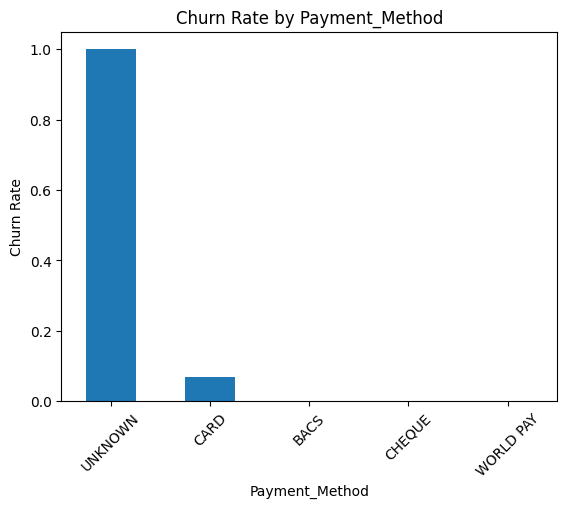


==== Band ====

target       0      1
Band                 
Band A   77.94  22.06
Band B   82.64  17.36
Band C1  89.02  10.98
Band C2  91.74   8.26
Band D   92.91   7.09
Band E   93.57   6.43
Band F   93.66   6.34
Band F1  93.82   6.18
Band F2  93.30   6.70
Band G   93.35   6.65
Band H   93.24   6.76
Band I   91.78   8.22
Band J   93.37   6.63
Group    94.19   5.81
Unknown   5.00  95.00

Counts:
 Band
Band B     30492
Band C1    23168
Band D     17720
Band C2    14737
Band E      9001
Band F1     5433
Band A      3523
Band F2     2939
Band G      2242
Band F      2193
Group        930
Band H       769
Band I       365
Band J       362
Unknown       20
Name: count, dtype: int64


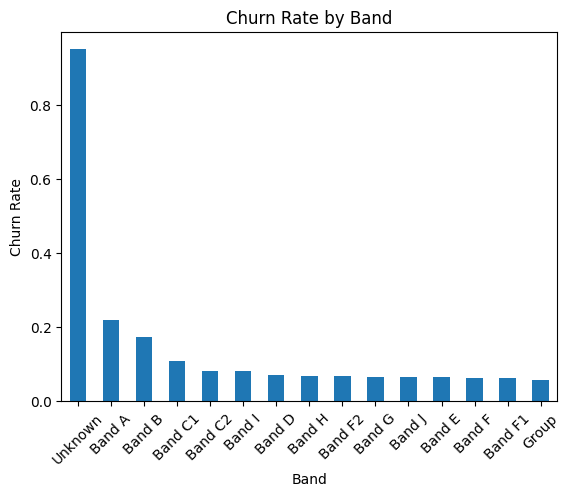


==== Connection_Group ====

target                0      1
Connection_Group              
1                 85.99  14.01
10+               97.77   2.23
2                 91.57   8.43
3                 94.11   5.89
4-9               96.12   3.88
Unknown           41.80  58.20
independent       80.13  19.87

Counts:
 Connection_Group
1              35435
independent    23118
4-9            19435
2              18167
3               9830
10+             7787
Unknown          122
Name: count, dtype: int64


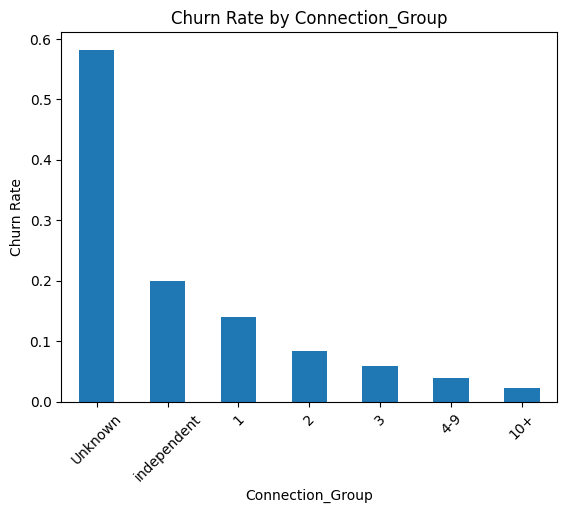


==== Tenure_Group ====

target            0      1
Tenure_Group              
1             78.19  21.81
2             84.00  16.00
3             86.23  13.77
4+            92.87   7.13
Unknown       87.59  12.41

Counts:
 Tenure_Group
4+         71422
1          18026
2          13198
3          10273
Unknown      975
Name: count, dtype: int64


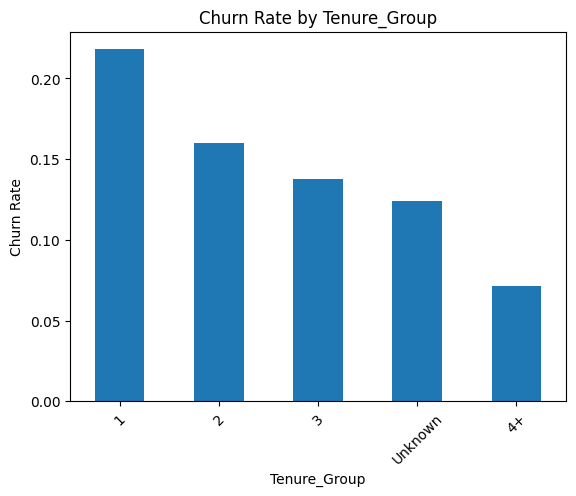


==== Anchor_Group ====

target            0      1
Anchor_Group              
1             85.99  14.01
10+           97.77   2.23
2             91.57   8.43
3             94.11   5.89
4-9           96.12   3.88
Unknown       41.80  58.20
independent   80.13  19.87

Counts:
 Anchor_Group
1              35435
independent    23118
4-9            19435
2              18167
3               9830
10+             7787
Unknown          122
Name: count, dtype: int64


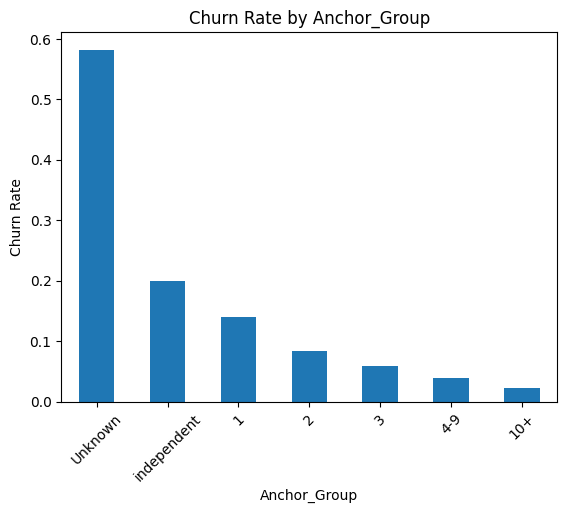

In [23]:
import matplotlib.pyplot as plt

cat_cols = [
    'Payment_Method',
    'Band',
    'Connection_Group',
    'Tenure_Group',
    'Anchor_Group',
]

for col in cat_cols:
    print(f"\n==== {col} ====\n")
    
    # ── Handle missing values (important) ────────────────
    df[col] = df[col].fillna('Unknown')
    
    # ── Crosstab (% distribution) ───────────────────────
    ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
    print(ct.round(2))
    
    # ── Add count (VERY IMPORTANT for interpretation) ───
    count = df[col].value_counts()
    print("\nCounts:\n", count)
    
    # ── Churn Rate ─────────────────────────────────────
    churn_rate = (
        df.groupby(col)['target']
        .mean()
        .sort_values(ascending=False)
    )
    
    # ── Plot ───────────────────────────────────────────
    plt.figure()
    churn_rate.plot(kind='bar')
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.show()

In [24]:
from scipy.stats import chi2_contingency

cat_cols = [
    'Payment_Method',
    'Band',
    'Connection_Group',
    'Tenure_Group',
    'Anchor_Group',
   
]

results = []

for col in cat_cols:
    # Create contingency table
    table = pd.crosstab(df[col], df['target'])
    
    # Apply Chi-square test
    chi2, p, dof, expected = chi2_contingency(table)
    
    results.append((col, chi2, p))

# Convert to DataFrame
res_df = pd.DataFrame(results, columns=['Feature', 'Chi2', 'p_value'])

# Sort by significance
res_df = res_df.sort_values('p_value')

print(res_df)

            Feature          Chi2  p_value
0    Payment_Method  68301.191365      0.0
1              Band   2721.465259      0.0
2  Connection_Group   4420.240766      0.0
3      Tenure_Group   3628.833560      0.0
4      Anchor_Group   4420.240766      0.0


In [25]:
print(df.columns)

Index(['Co_Ref', 'Renewal_Month', 'Discount_Amount', 'Sustainability_Score',
       'Total_Renewal_Score_New', 'Last_Years_Price', 'Auto_Renewal_Score',
       'Status_Scores', 'Anchoring_Score', 'Tenure_Scores',
       'Proforma_Auto_Renewal', 'Proforma_World_Pay_Token',
       'Current_Anchorings', 'Current_Anchor_List', 'Payment_Timeframe',
       'Proforma_Account_Stage', 'Proforma_Audit_Status',
       'Current_Auto_Renewal_Flag', 'Current_World_Pay_Token',
       'Renewal_Score_At_Release', 'Proforma_Membership_Status',
       'Proforma_Approved_Lists', 'Tenure_Years', 'Band', 'Prospect_Status',
       'Total_Net_Paid', 'Payment_Method', 'Total_Amount', 'Connection_Group',
       'Tenure_Group', '#_of_Connection', 'Last_Band', 'Last_Total_Net_Paid',
       'Last_Connections', 'Anchor_Group', 'Renewal_Year',
       'Agent_Renewal_Pitch_Category_renewal',
       'Customer_Renewal_Response_Category_renewal',
       'Agent_Response_Category_renewal',
       'Membership_Renewal_Decisi

In [26]:
cols = [ '#_of_Connection', 'Last_Connections', 'Connection_Group' ]

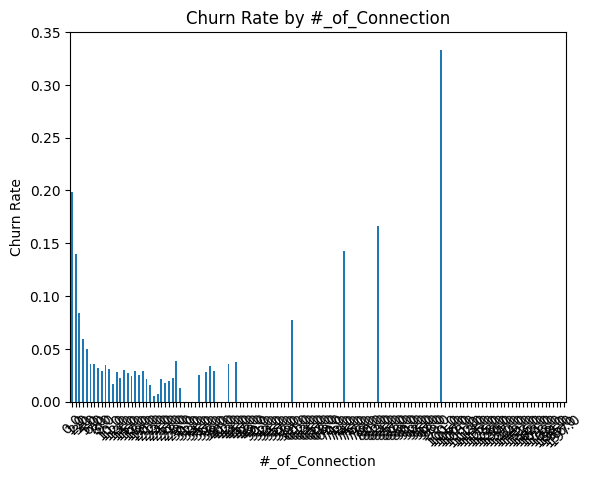

In [27]:
import matplotlib.pyplot as plt

churn_rate = df.groupby('#_of_Connection')['target'].mean().sort_index()

plt.figure()
churn_rate.plot(kind='bar')
plt.title("Churn Rate by #_of_Connection")
plt.ylabel("Churn Rate")
plt.xlabel("#_of_Connection")
plt.xticks(rotation=45)
plt.show()

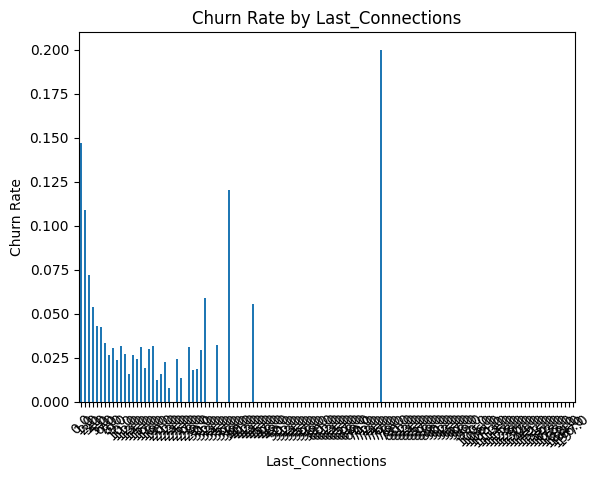

In [28]:
churn_rate = df.groupby('Last_Connections')['target'].mean().sort_index()

plt.figure()
churn_rate.plot(kind='bar')
plt.title("Churn Rate by Last_Connections")
plt.ylabel("Churn Rate")
plt.xlabel("Last_Connections")
plt.xticks(rotation=45)
plt.show()

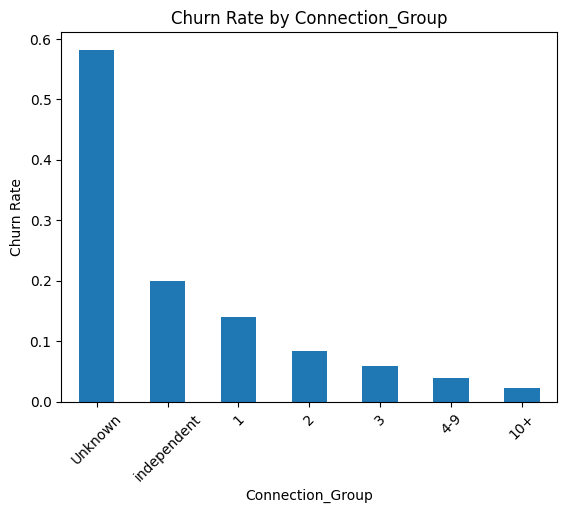

In [29]:
churn_rate = df.groupby('Connection_Group')['target'].mean().sort_values(ascending=False)

plt.figure()
churn_rate.plot(kind='bar')
plt.title("Churn Rate by Connection_Group")
plt.ylabel("Churn Rate")
plt.xlabel("Connection_Group")
plt.xticks(rotation=45)
plt.show()

In [30]:
from scipy.stats import pointbiserialr

cols = ['#_of_Connection', 'Last_Connections']

for col in cols:
    print(f"\n==== {col} ====\n")
    
    # Drop nulls just in case
    temp = df[[col, 'target']].dropna()
    
    corr, p = pointbiserialr(temp['target'], temp[col])
    
    print("Correlation:", round(corr, 4))
    print("p-value:", p)


==== #_of_Connection ====

Correlation: -0.1018
p-value: 1.5031852555041445e-259

==== Last_Connections ====

Correlation: -0.0846
p-value: 5.3707841702552703e-107


In [31]:
df = df.drop(columns=['#_of_Connection', 'Last_Connections' , 'Payment_Method'])

In [32]:
len(df.columns)

print(df.columns)

Index(['Co_Ref', 'Renewal_Month', 'Discount_Amount', 'Sustainability_Score',
       'Total_Renewal_Score_New', 'Last_Years_Price', 'Auto_Renewal_Score',
       'Status_Scores', 'Anchoring_Score', 'Tenure_Scores',
       'Proforma_Auto_Renewal', 'Proforma_World_Pay_Token',
       'Current_Anchorings', 'Current_Anchor_List', 'Payment_Timeframe',
       'Proforma_Account_Stage', 'Proforma_Audit_Status',
       'Current_Auto_Renewal_Flag', 'Current_World_Pay_Token',
       'Renewal_Score_At_Release', 'Proforma_Membership_Status',
       'Proforma_Approved_Lists', 'Tenure_Years', 'Band', 'Prospect_Status',
       'Total_Net_Paid', 'Total_Amount', 'Connection_Group', 'Tenure_Group',
       'Last_Band', 'Last_Total_Net_Paid', 'Anchor_Group', 'Renewal_Year',
       'Agent_Renewal_Pitch_Category_renewal',
       'Customer_Renewal_Response_Category_renewal',
       'Agent_Response_Category_renewal',
       'Membership_Renewal_Decision_renewal', 'Serious_Complaint_renewal',
       'Other_Complain

In [33]:
print(df['Membership_Renewal_Decision_renewal'].value_counts())

Membership_Renewal_Decision_renewal
No        15377
Yes        1208
Yes/No        1
Name: count, dtype: int64


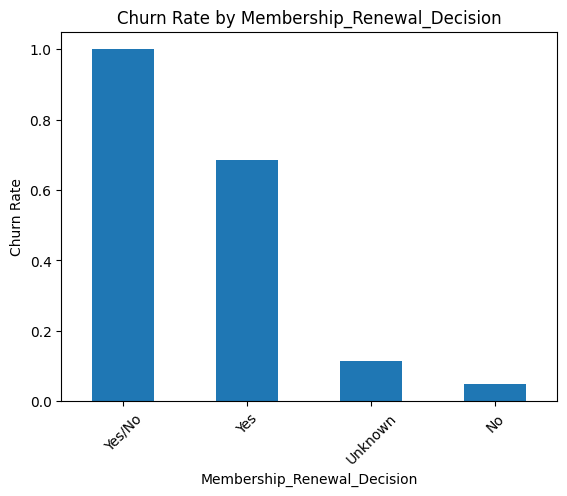

In [34]:
import matplotlib.pyplot as plt

# Clean column
df['Membership_Renewal_Decision_renewal'] = (
    df['Membership_Renewal_Decision_renewal']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
)

# Churn rate
churn_rate = (
    df.groupby('Membership_Renewal_Decision_renewal')['target']
    .mean()
    .sort_values(ascending=False)
)

plt.figure()
churn_rate.plot(kind='bar')
plt.title("Churn Rate by Membership_Renewal_Decision")
plt.ylabel("Churn Rate")
plt.xlabel("Membership_Renewal_Decision")
plt.xticks(rotation=45)
plt.show()

In [35]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df['Membership_Renewal_Decision_renewal'],
    df['target']
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 4648.220910063991
p-value: 0.0


In [36]:
# Yes/No → ~100% churn 🚨
# Yes → ~70% churn ⚠️
# Unknown → ~10%
# No → ~5%

# 👉 This is an extremely strong separation

In [37]:
df = df.drop(columns=['Membership_Renewal_Decision_renewal'], errors='ignore')

In [38]:
df['Analysed_Call_renewal'].value_counts()


Analysed_Call_renewal
1.0    16999
Name: count, dtype: int64

In [39]:
df = df.drop(columns=['Analysed_Call_renewal'])

In [40]:

print(df['Last_Band'].value_counts())
print(df['Band'].value_counts())

Last_Band
Band B     16625
Band C1    13677
Band D     10806
Band C2     9142
Band E      5575
Band F1     2935
Band F      2041
Band A      1809
Band F2     1616
Band G      1421
Group        609
Band H       477
Band I       263
Band J       196
Name: count, dtype: int64
Band
Band B     30492
Band C1    23168
Band D     17720
Band C2    14737
Band E      9001
Band F1     5433
Band A      3523
Band F2     2939
Band G      2242
Band F      2193
Group        930
Band H       769
Band I       365
Band J       362
Unknown       20
Name: count, dtype: int64


In [41]:
cols = [
    'Mentioned_Competitors_renewal',
    'Competitor_Benefits_Mentioned_renewal',
    'Topic_Introduced_By_renewal'
]

for col in cols:
    print(f"\n==== {col} ====")
    print(df[col].value_counts(dropna=False))


==== Mentioned_Competitors_renewal ====
Mentioned_Competitors_renewal
NaN                                                                                                     96903
No                                                                                                      15652
Yes                                                                                                      1336
44. The customer also mentioned that Safe Contractor's product is not like-for-like with the others.        1
XXXX                                                                                                        1
5% price increase is "quite a hefty hike for no additional benefit for us".                                 1
Name: count, dtype: int64

==== Competitor_Benefits_Mentioned_renewal ====
Competitor_Benefits_Mentioned_renewal
NaN                                                 97337
Not Applicable                                      12322
Not Discussed                           

In [42]:
# # ───────────────────────────────────────────────────────────
# # Handle competitor + topic columns (final version)
# # ───────────────────────────────────────────────────────────

# # 1. Mentioned Competitors → flag
# df['competitor_mentioned_flag'] = df['Mentioned_Competitors_renewal'].notnull().astype(int)

# # 2. Drop messy high-cardinality column
# df = df.drop(columns=['Competitor_Benefits_Mentioned_renewal'], errors='ignore')

# # 3. Topic Introduced By → clean + encode
# df['Topic_Introduced_By_renewal'] = df['Topic_Introduced_By_renewal'].fillna('Unknown')

# df = pd.get_dummies(
#     df,
#     columns=['Topic_Introduced_By_renewal'],
#     drop_first=True
# )

# # 4. Drop original competitor column
# df = df.drop(columns=['Mentioned_Competitors_renewal'], errors='ignore')

# # ───────────────────────────────────────────────────────────
# # Done: 
# # - competitor_mentioned_flag created
# # - noisy column removed
# # - topic column encoded
# # ───────────────────────────────────────────────────────────


==== Mentioned_Competitors_renewal ====
target                                                   0      1
Mentioned_Competitors_renewal                                    
44. The customer also mentioned that Safe Contr...  100.00   0.00
5% price increase is "quite a hefty hike for no...  100.00   0.00
NaN                                                  88.59  11.41
No                                                   91.16   8.84
XXXX                                                100.00   0.00
Yes                                                  83.23  16.77


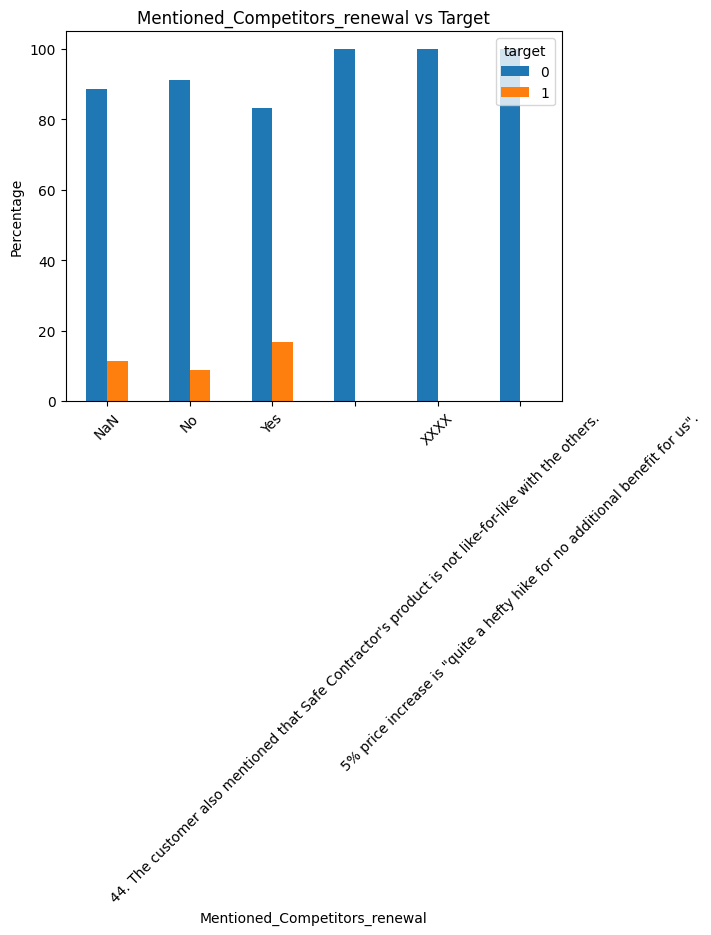


==== Competitor_Benefits_Mentioned_renewal ====
target                                                  0      1
Competitor_Benefits_Mentioned_renewal                           
Advice                                              100.0    0.0
Assistance                                          100.0    0.0
Better Accreditation                                100.0    0.0
Better Offering                                     100.0    0.0
Better Price                                         75.0   25.0
...                                                   ...    ...
The customer mentions that they can get better ...  100.0    0.0
The customer mentions that they can get similar...    0.0  100.0
The customer mentions that they were expecting ...  100.0    0.0
The customer mentions using the ECA for risk as...  100.0    0.0
better service                                      100.0    0.0

[86 rows x 2 columns]


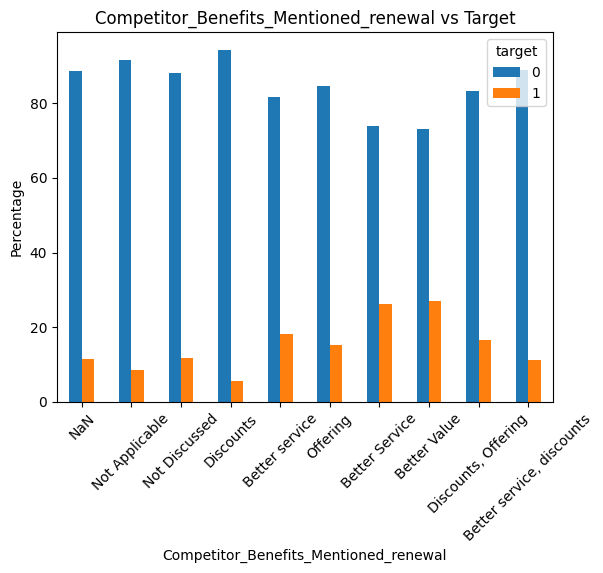


==== Topic_Introduced_By_renewal ====
target                           0      1
Topic_Introduced_By_renewal              
Agent                        92.69   7.31
Customer                     86.61  13.39
NaN                          88.59  11.41
Not Discussed                90.19   9.81


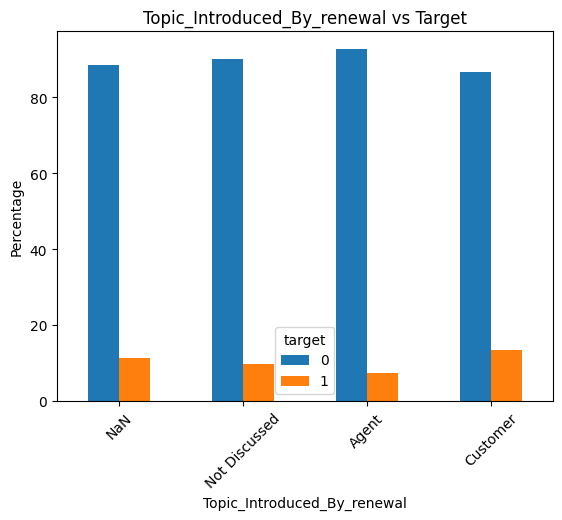


=== Chi-Square Results ===
                                 Feature  Chi2_Score       p_value
1  Competitor_Benefits_Mentioned_renewal  291.687224  1.867679e-24
0          Mentioned_Competitors_renewal  134.567009  2.552805e-27
2            Topic_Introduced_By_renewal   93.186187  4.529811e-20


In [43]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2_contingency

cols = [
    'Mentioned_Competitors_renewal',
    'Competitor_Benefits_Mentioned_renewal',
    'Topic_Introduced_By_renewal'
]

results = []

for col in cols:
    
    if col not in df.columns:
        print(f"\n⚠️ Skipping {col} (not in df)")
        continue
    
    print(f"\n==== {col} ====")
    
    # Crosstab
    ct = pd.crosstab(df[col].fillna('NaN'), df['target'], normalize='index') * 100
    print(ct.round(2))
    
    # Plot top 10
    top_vals = df[col].fillna('NaN').value_counts().head(10).index
    ct_top = ct.loc[top_vals]
    
    ct_top.plot(kind='bar')
    plt.title(f'{col} vs Target')
    plt.xlabel(col)
    plt.ylabel('Percentage')
    plt.xticks(rotation=45)
    plt.show()
    
    # Chi-square
    contingency = pd.crosstab(df[col].fillna('NaN'), df['target'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    results.append({
        'Feature': col,
        'Chi2_Score': chi2,
        'p_value': p
    })

chi_df = pd.DataFrame(results).sort_values(by='Chi2_Score', ascending=False)

print("\n=== Chi-Square Results ===")
print(chi_df)

In [44]:
# competitor signal
df['competitor_mentioned_flag'] = df['Mentioned_Competitors_renewal'].notnull().astype(int)

# topic signal
df['topic_customer_flag'] = (df['Topic_Introduced_By_renewal'] == 'Customer').astype(int)

# optional
df['topic_agent_flag'] = (df['Topic_Introduced_By_renewal'] == 'Agent').astype(int)

In [45]:
df = df.drop(columns=[
    'Competitor_Benefits_Mentioned_renewal',
    'Mentioned_Competitors_renewal',
    'Topic_Introduced_By_renewal'
], errors='ignore')

In [46]:
# When a customer mentions competitors, it usually means:

# Comparing alternatives
# Evaluating switching
# Price dissatisfaction
# Value concerns

# 💥 All are strong churn signals


==== Prospect_Status ====
target                               0      1
Prospect_Status                              
Renewed                         100.00   0.00
Application and Money In         99.98   0.02
No Longer Trading                 6.28  93.72
Do Not Work for Client            2.10  97.90
Not Value for Money               1.59  98.41
Refused to Discuss                1.53  98.47
Competitor Accreditation          2.24  97.76
Non Responsive                    0.29  99.71
Not Affordable                    0.33  99.67
Existing Safecontractor Member    8.72  91.28


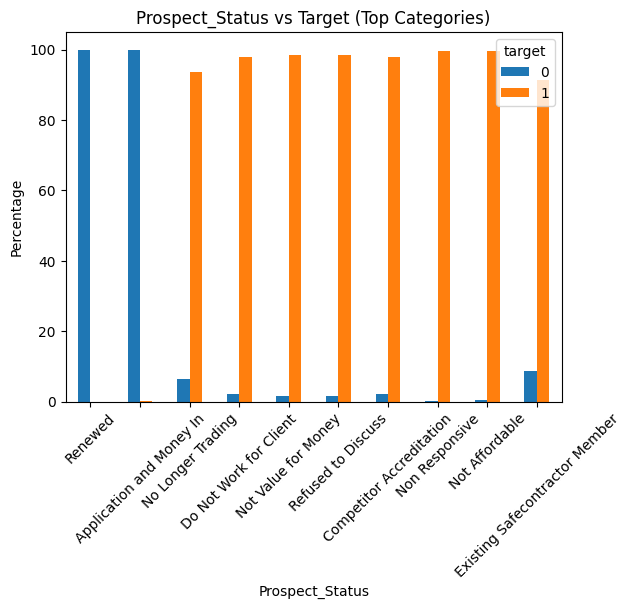


==== Proforma_Account_Stage ====
target                      0       1
Proforma_Account_Stage               
Published               93.84    6.16
Membership Only         70.04   29.96
Renewal Process         89.76   10.24
NaN                     86.91   13.09
Vetting                 68.79   31.21
Suspended               88.06   11.94
Retired                  0.00  100.00
vetting                  0.00  100.00


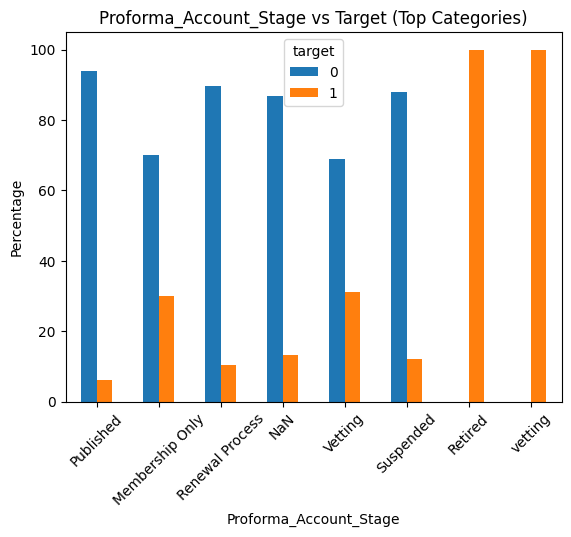


==== Proforma_Audit_Status ====
target                                                  0      1
Proforma_Audit_Status                                           
Accredited                                          93.86   6.14
NaN                                                 86.91  13.09
Failed- Renewal Questionnaire not received          72.57  27.43
Renewal Questionnaire Received                      91.61   8.39
Failed- Renewal Additional Information Not Rece...  74.47  25.53
Failed- Initial additional info not received        67.20  32.80
Renewal Questionnaire Sent                          92.11   7.89
Failed- Initial Questionnaire not received          63.08  36.92
Initial Questionnaire Received                      67.23  32.77
Renewal report sent - Awaiting information          89.17  10.83


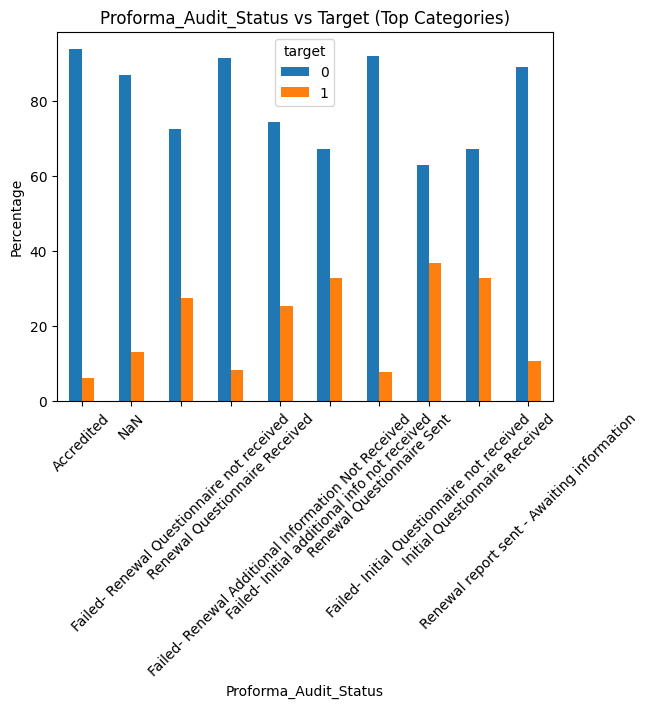

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

cols = [
    'Prospect_Status',
    'Proforma_Account_Stage',
    'Proforma_Audit_Status'
]

for col in cols:
    
    if col not in df.columns:
        print(f"\n⚠️ Skipping {col}")
        continue
    
    print(f"\n==== {col} ====")
    
    # Take top 10 categories for readability
    top_vals = df[col].fillna('NaN').value_counts().head(10).index
    
    # Crosstab (%)
    ct = pd.crosstab(
        df[col].fillna('NaN'),
        df['target'],
        normalize='index'
    ) * 100
    
    ct_top = ct.loc[top_vals]
    
    print(ct_top.round(2))
    
    # Plot
    ct_top.plot(kind='bar')
    plt.title(f'{col} vs Target (Top Categories)')
    plt.xlabel(col)
    plt.ylabel('Percentage')
    plt.xticks(rotation=45)
    plt.show()

In [48]:
cols = [
    # 'Membership_Renewal_Decision_renewal',
    'Prospect_Status',
    'Proforma_Account_Stage',
    'Proforma_Audit_Status'
]

for col in cols:
     print(df[col].value_counts())
     print()

Prospect_Status
Renewed                                            94825
Application and Money In                            5892
No Longer Trading                                   2387
Do Not Work for Client                              2377
Not Value for Money                                 2196
Refused to Discuss                                  1180
Competitor Accreditation                             984
Non Responsive                                       698
Not Affordable                                       612
Existing Safecontractor Member                       436
Cannot Pass Audit                                    413
Not to be contacted                                  409
Promised to Pay - Fees not Received                  210
Insufficient Contract Value                          200
Need Time To Consider > 30 days                      164
Duplicate Entry                                      157
Poor Customer Service                                154
Supply Only    

In [49]:
df['Proforma_Account_Stage'] = df['Proforma_Account_Stage'].str.strip().str.title()

counts = df['Proforma_Account_Stage'].value_counts()

rare = counts[counts < 100].index

df['Proforma_Account_Stage'] = df['Proforma_Account_Stage'].replace(rare, 'Other')

In [50]:
df['stage_high_risk_flag'] = df['Proforma_Account_Stage'].isin([
    'Membership Only',
    'Vetting'
]).astype(int)

df['stage_low_risk_flag'] = (df['Proforma_Account_Stage'] == 'Published').astype(int)

In [51]:
df = df.drop(columns=['Prospect_Status'])
df = df.drop(columns=['Proforma_Account_Stage'])

In [52]:
print(len(df.columns))

63


In [53]:
print(df.columns)
print(len(df.columns))

Index(['Co_Ref', 'Renewal_Month', 'Discount_Amount', 'Sustainability_Score',
       'Total_Renewal_Score_New', 'Last_Years_Price', 'Auto_Renewal_Score',
       'Status_Scores', 'Anchoring_Score', 'Tenure_Scores',
       'Proforma_Auto_Renewal', 'Proforma_World_Pay_Token',
       'Current_Anchorings', 'Current_Anchor_List', 'Payment_Timeframe',
       'Proforma_Audit_Status', 'Current_Auto_Renewal_Flag',
       'Current_World_Pay_Token', 'Renewal_Score_At_Release',
       'Proforma_Membership_Status', 'Proforma_Approved_Lists', 'Tenure_Years',
       'Band', 'Total_Net_Paid', 'Total_Amount', 'Connection_Group',
       'Tenure_Group', 'Last_Band', 'Last_Total_Net_Paid', 'Anchor_Group',
       'Renewal_Year', 'Agent_Renewal_Pitch_Category_renewal',
       'Customer_Renewal_Response_Category_renewal',
       'Agent_Response_Category_renewal', 'Serious_Complaint_renewal',
       'Other_Complaint_renewal', 'Discussion_on_Price_Increase_renewal',
       'Renewal_Impact_Due_to_Price_Increase_r

In [54]:
extra_in_df = set(df.columns) - set(df_copy.columns)
print("Extra in df:", extra_in_df)

Extra in df: {'competitor_mentioned_flag', 'Customer_Response_flag', 'topic_agent_flag', 'stage_high_risk_flag', 'days_since_registration', 'target', 'Call_attend_status_renewal', 'Explicit_Switching_Intent_flag', 'Discount_Offered_flag', 'stage_low_risk_flag', 'cancel_flag', 'topic_customer_flag'}


In [55]:
dropped_cols = list(set(df_copy.columns) - set(df.columns))
print("Dropped columns:", dropped_cols)

Dropped columns: ['Starting_Vat', 'Last_Connections', 'Registration_Date', 'cc_pricing_sentiment_impact_cc', 'cc_contractor_sentiment_start_score_cc', 'Closed_Date', 'cc_contractor_sentiment_overall_score_cc', 'Starting_Gross', 'Call_ID_renewal', 'cc_refund_discussed_cc', 'Explicit_Switching_Intent_renewal', 'DateTime_Out', 'Last_Renewal', 'cc_pricing_mentioned_cc', 'cc_contractor_complained_cc', 'cc_issues_within_questionnaire_cc', 'Analysed_Call_cc', 'cc_process_complexity_concerns_cc', 'Customer_Reaction_Category_renewal', 'Starting_PQQ_Net', 'cc_contractor_sentiment_cc', 'cc_customer_issues_concerns_cc', 'Prospect_Status', '#_of_Connection', 'Direction_cc', 'Analysed_Call_renewal', 'Call_Date_cc', 'cc_questionnaire_completion_cc', 'Membership_Net', 'Starting_Package_Net', 'cc_urgency_getting_on_site_cc', 'Gross', 'Call_Year_cc', 'Call_Direction_renewal', 'Starting_Membership_Net', 'PQQNet', 'Desire_To_Cancel_renewal', 'cc_care_package_cc', 'Competitor_Benefits_Mentioned_renewal', '

In [56]:
# redundancy in total agent flag 


df = df.drop(columns=['topic_agent_flag'], errors='ignore')

# 👉 These two are correlated / redundant

# Because:

# If customer = 1 → agent = 0
# If agent = 1 → customer = 0

# 👉 Model gets duplicate information


In [57]:
extra_in_df = set(df.columns) - set(df_copy.columns)
# print("Extra in df:", extra_in_df)

print(set(df.columns) - set(extra_in_df))
print(len(set(df.columns) - set(extra_in_df)))

{'Anchor_Group', 'Discount_or_Waiver_Requested_renewal', 'Call_Number_renewal', 'Payment_Timeframe', 'Sustainability_Score', 'Discussion_on_Price_Increase_renewal', 'Connection_Group', 'Current_Anchorings', 'Tenure_Years', 'Call_Year_renewal', 'Current_World_Pay_Token', 'Status_Scores', 'Auto_Renewal_Score', 'Renewal_Year', 'Total_Renewal_Score_New', 'Current_Auto_Renewal_Flag', 'Agent_Renewal_Pitch_Category_renewal', 'Total_Net_Paid', 'Current_Anchor_List', 'Last_Years_Price', 'Customer_Renewal_Response_Category_renewal', 'Customer_Asked_For_Justification_renewal', 'Proforma_Approved_Lists', 'Last_Total_Net_Paid', 'Agent_Flagged_Membership_Status_Alert_renewal', 'Discount_Amount', 'Tenure_Scores', 'Renewal_Month', 'Percentage_Price_Increase_Mentioned_renewal', 'Price_Range_Mentioned_renewal', 'Proforma_World_Pay_Token', 'Renewal_Score_At_Release', 'Serious_Complaint_renewal', 'Agent_Response_Category_renewal', 'Proforma_Audit_Status', 'Agent_Renewal_Initiation_renewal', 'Total_Amount'

In [58]:
print(df['Call_Number_renewal'].value_counts())

Call_Number_renewal
1.0      14778
2.0       8045
3.0       3559
4.0       1826
5.0        968
6.0        613
7.0        427
8.0        298
9.0        218
10.0       181
11.0       113
12.0       106
13.0        74
14.0        65
15.0        53
16.0        47
17.0        37
18.0        24
19.0        18
20.0        17
23.0        15
21.0        12
24.0        11
25.0        10
31.0         9
26.0         8
22.0         8
32.0         6
29.0         6
27.0         6
35.0         4
34.0         4
38.0         4
30.0         4
33.0         3
45.0         2
39.0         2
43.0         2
28.0         2
165.0        1
51.0         1
44.0         1
59.0         1
41.0         1
36.0         1
53.0         1
47.0         1
46.0         1
85.0         1
40.0         1
Name: count, dtype: int64


In [59]:
x = [
    'Call_Number_renewal',
    'Call_Year_renewal',
]

df = df.drop(columns = x)

In [60]:
x = [
    'Renewal_Month',
    'Renewal_Year'
]

df = df.drop(columns = x)



In [61]:
extra_in_df = set(df.columns) - set(df_copy.columns)
# print("Extra in df:", extra_in_df)

print(set(df.columns) - set(extra_in_df))
print(len(set(df.columns) - set(extra_in_df)))

{'Anchor_Group', 'Discount_or_Waiver_Requested_renewal', 'Payment_Timeframe', 'Sustainability_Score', 'Discussion_on_Price_Increase_renewal', 'Connection_Group', 'Current_Anchorings', 'Tenure_Years', 'Current_World_Pay_Token', 'Status_Scores', 'Auto_Renewal_Score', 'Total_Renewal_Score_New', 'Current_Auto_Renewal_Flag', 'Agent_Renewal_Pitch_Category_renewal', 'Total_Net_Paid', 'Current_Anchor_List', 'Last_Years_Price', 'Customer_Renewal_Response_Category_renewal', 'Customer_Asked_For_Justification_renewal', 'Proforma_Approved_Lists', 'Last_Total_Net_Paid', 'Agent_Flagged_Membership_Status_Alert_renewal', 'Discount_Amount', 'Tenure_Scores', 'Percentage_Price_Increase_Mentioned_renewal', 'Price_Range_Mentioned_renewal', 'Proforma_World_Pay_Token', 'Renewal_Score_At_Release', 'Serious_Complaint_renewal', 'Agent_Response_Category_renewal', 'Proforma_Audit_Status', 'Agent_Renewal_Initiation_renewal', 'Total_Amount', 'Proforma_Auto_Renewal', 'Call_Reschedule_Request_renewal', 'Last_Band', 'P

In [62]:
print(len(df.columns))

58


In [63]:
print(df['Payment_Timeframe'].value_counts())

Payment_Timeframe
 0.0      28880
-1.0       3014
 1.0       2936
-2.0       2045
 2.0       1989
          ...  
 153.0        1
-297.0        1
-193.0        1
-689.0        1
-247.0        1
Name: count, Length: 295, dtype: int64


In [64]:
df['Payment_Timeframe'] = np.sign(df['Payment_Timeframe']) * np.log1p(abs(df['Payment_Timeframe']))

In [65]:
print(df['Payment_Timeframe'].value_counts())

Payment_Timeframe
 0.000000    28880
-0.693147     3014
 0.693147     2936
-1.098612     2045
 1.098612     1989
             ...  
 5.036953        1
-5.697093        1
-5.267858        1
-6.536692        1
-5.513429        1
Name: count, Length: 295, dtype: int64


# =============================================================================================

In [66]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()
print(num_cols)
print(len(num_cols))

['Sustainability_Score', 'Total_Renewal_Score_New', 'Last_Years_Price', 'Auto_Renewal_Score', 'Status_Scores', 'Anchoring_Score', 'Tenure_Scores', 'Current_Anchorings', 'Payment_Timeframe', 'Renewal_Score_At_Release', 'Proforma_Approved_Lists', 'Tenure_Years', 'Total_Net_Paid', 'Total_Amount', 'Last_Total_Net_Paid', 'Explicit_Switching_Intent_flag', 'Discount_Offered_flag', 'Customer_Response_flag', 'cancel_flag', 'target', 'days_since_registration', 'Call_attend_status_renewal', 'competitor_mentioned_flag', 'topic_customer_flag', 'stage_high_risk_flag', 'stage_low_risk_flag']
26


In [67]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(cat_cols)
print(len(cat_cols))

['Co_Ref', 'Discount_Amount', 'Proforma_Auto_Renewal', 'Proforma_World_Pay_Token', 'Current_Anchor_List', 'Proforma_Audit_Status', 'Current_Auto_Renewal_Flag', 'Current_World_Pay_Token', 'Proforma_Membership_Status', 'Band', 'Connection_Group', 'Tenure_Group', 'Last_Band', 'Anchor_Group', 'Agent_Renewal_Pitch_Category_renewal', 'Customer_Renewal_Response_Category_renewal', 'Agent_Response_Category_renewal', 'Serious_Complaint_renewal', 'Other_Complaint_renewal', 'Discussion_on_Price_Increase_renewal', 'Renewal_Impact_Due_to_Price_Increase_renewal', 'Discount_or_Waiver_Requested_renewal', 'Call_Reschedule_Request_renewal', 'Agent_Flagged_Membership_Status_Alert_renewal', 'Agent_Renewal_Initiation_renewal', 'Explicit_Competitor_Mention_renewal', 'Price_Switching_Mentioned_renewal', 'Competitor_Value_Comparison_renewal', 'Percentage_Price_Increase_Mentioned_renewal', 'Monetary_Price_Increase_Mentioned_renewal', 'Price_Range_Mentioned_renewal', 'Customer_Asked_For_Justification_renewal']
3

C:\Users\Asus\AppData\Local\Temp\ipykernel_22448\1926294870.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


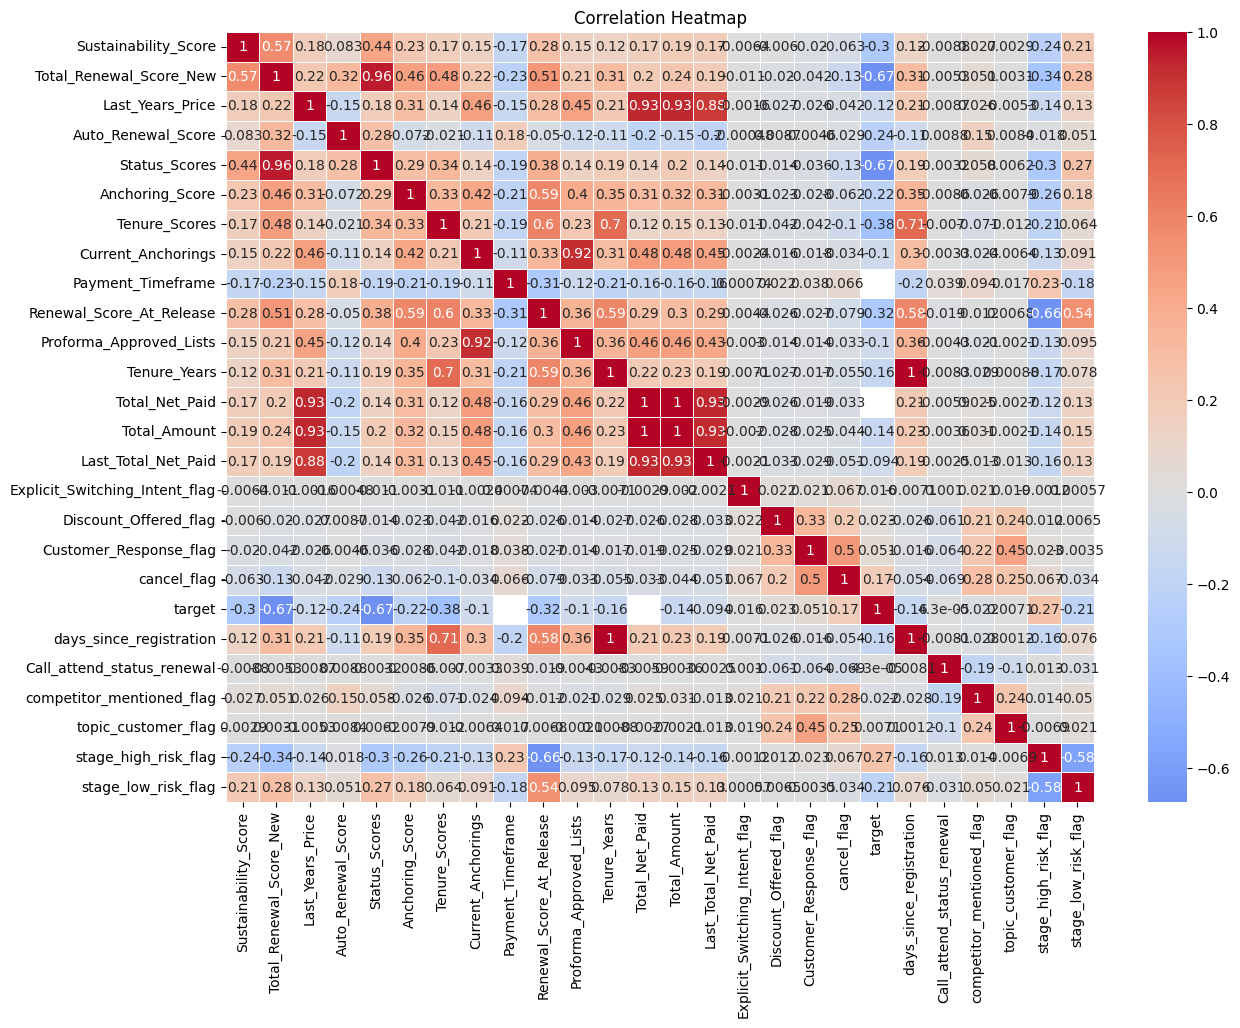

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True,              # keep only one
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

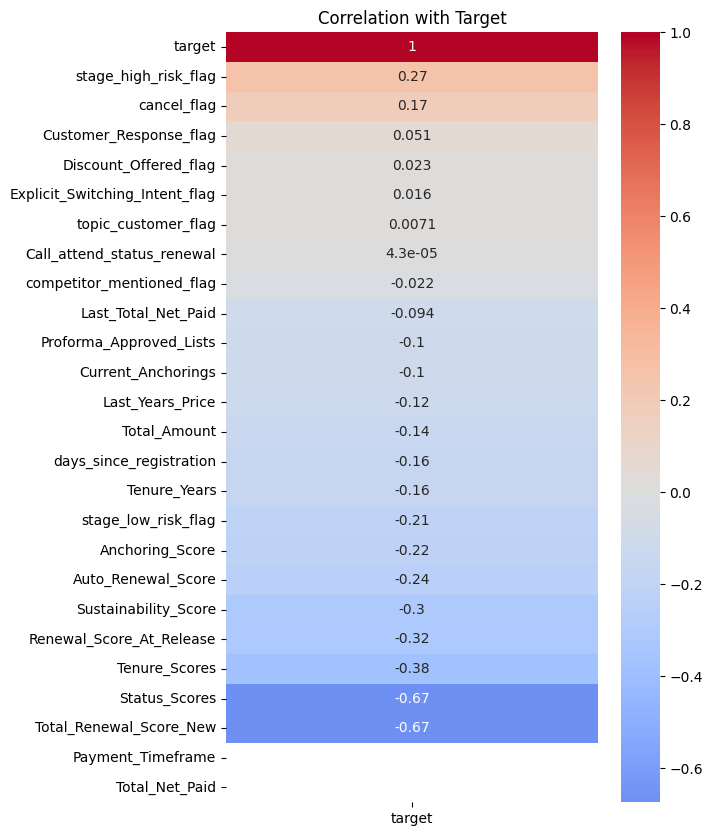

In [69]:
corr_target = df.corr(numeric_only=True)[['target']].sort_values(by='target', ascending=False)

plt.figure(figsize=(6, 10))
sns.heatmap(
    corr_target,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation with Target")
plt.show()

In [70]:
import numpy as np

corr_matrix = df.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [col for col in upper.columns if any(upper[col] > 0.9)]

print("Highly correlated:", high_corr)

Highly correlated: ['Status_Scores', 'Proforma_Approved_Lists', 'Total_Net_Paid', 'Total_Amount', 'Last_Total_Net_Paid', 'days_since_registration']


In [71]:
df['pct_inc_total_net_paid'] = (
    (df['Total_Net_Paid'] - df['Last_Total_Net_Paid']) 
    / (df['Last_Total_Net_Paid'] + 1e-5)
)

In [72]:
# ✅ 1. Financial cluster (VERY CLEAR)
drop = ['Total_Amount', 'Last_Total_Net_Paid']

df = df.drop(columns=drop, errors='ignore')



# 👉 These are almost duplicates

# ✔ Keep ONLY 1–2

In [73]:
# 👉 Highly correlated with:

# Tenure_Years
# ✔ Keep ONLY ONE

# Prefer:

keep = ['Tenure_Years']
drop = ['days_since_registration']

df.drop(columns=drop, errors='ignore', inplace=True)

# 👉 Easier interpretation + cleaner

In [74]:
print(len(df.columns))

56


In [75]:
from scipy.stats import chi2_contingency



results = []

for col in cat_cols:
    table = pd.crosstab(df[col], df['target'])
    
    chi2, p, _, _ = chi2_contingency(table)
    
    results.append((col, chi2, p))

chi_df = pd.DataFrame(results, columns=['Feature', 'Chi2', 'p_value'])
chi_df = chi_df.sort_values('p_value')

print(chi_df)

                                          Feature          Chi2        p_value
0                                          Co_Ref  79981.857073   0.000000e+00
16                Agent_Response_Category_renewal   3065.750992   0.000000e+00
13                                   Anchor_Group   4420.240766   0.000000e+00
11                                   Tenure_Group   3628.833560   0.000000e+00
10                               Connection_Group   4420.240766   0.000000e+00
9                                            Band   2721.465259   0.000000e+00
8                      Proforma_Membership_Status   8700.121536   0.000000e+00
15     Customer_Renewal_Response_Category_renewal   3190.508311   0.000000e+00
6                       Current_Auto_Renewal_Flag   2380.948863   0.000000e+00
7                         Current_World_Pay_Token   6588.385138   0.000000e+00
1                                 Discount_Amount  11791.651459   0.000000e+00
5                           Proforma_Audit_Status   

In [76]:
# [
#     'Discount_Amount',
#     'Current_World_Pay_Token',
#     'Current_Auto_Renewal_Flag',
#     'Proforma_Audit_Status',              # ⚠️ possible leakage
#     'Proforma_Membership_Status',         # ❌ likely leakage
#     'Connection_Group',
#     'Anchor_Group',
#     'Tenure_Group',
#     'Band',
#     'Agent_Response_Category_renewal',
#     'Customer_Renewal_Response_Category_renewal'
# ]




# 🚨 2. STRONG BUT CHECK FOR LEAKAGE
# [
#     'Proforma_Audit_Status',
#     'Proforma_Membership_Status'
# ]

# 👉 These are too strong → suspicious

# ❌ Recommendation:
# drop_cols += [
#     'Proforma_Audit_Status',
#     'Proforma_Membership_Status'
# ]

In [77]:
# 👉 From your Chi-square:

# Very low Chi2 ❌
# High p-values ❌
# Weak signal ❌

# 👉 That means:

# They are weak predictors, regardless of direction


df = df.drop(columns=[
    'Proforma_Audit_Status',
    'Proforma_Membership_Status',
    'Discussion_on_Price_Increase_renewal',
    'Agent_Flagged_Membership_Status_Alert_renewal',
    'Monetary_Price_Increase_Mentioned_renewal',
    'Customer_Asked_For_Justification_renewal',
    'Percentage_Price_Increase_Mentioned_renewal',
    'Price_Range_Mentioned_renewal'
], errors='ignore')

In [78]:
print(len(df.columns))

48


In [79]:
print(len(df.columns))
print(df.columns)

48
Index(['Co_Ref', 'Discount_Amount', 'Sustainability_Score',
       'Total_Renewal_Score_New', 'Last_Years_Price', 'Auto_Renewal_Score',
       'Status_Scores', 'Anchoring_Score', 'Tenure_Scores',
       'Proforma_Auto_Renewal', 'Proforma_World_Pay_Token',
       'Current_Anchorings', 'Current_Anchor_List', 'Payment_Timeframe',
       'Current_Auto_Renewal_Flag', 'Current_World_Pay_Token',
       'Renewal_Score_At_Release', 'Proforma_Approved_Lists', 'Tenure_Years',
       'Band', 'Total_Net_Paid', 'Connection_Group', 'Tenure_Group',
       'Last_Band', 'Anchor_Group', 'Agent_Renewal_Pitch_Category_renewal',
       'Customer_Renewal_Response_Category_renewal',
       'Agent_Response_Category_renewal', 'Serious_Complaint_renewal',
       'Other_Complaint_renewal',
       'Renewal_Impact_Due_to_Price_Increase_renewal',
       'Discount_or_Waiver_Requested_renewal',
       'Call_Reschedule_Request_renewal', 'Agent_Renewal_Initiation_renewal',
       'Explicit_Competitor_Mention_renewal'

In [80]:
df = df.drop(columns=['Last_Band'])

In [81]:
print(len(df.columns))

print(df.columns)

47
Index(['Co_Ref', 'Discount_Amount', 'Sustainability_Score',
       'Total_Renewal_Score_New', 'Last_Years_Price', 'Auto_Renewal_Score',
       'Status_Scores', 'Anchoring_Score', 'Tenure_Scores',
       'Proforma_Auto_Renewal', 'Proforma_World_Pay_Token',
       'Current_Anchorings', 'Current_Anchor_List', 'Payment_Timeframe',
       'Current_Auto_Renewal_Flag', 'Current_World_Pay_Token',
       'Renewal_Score_At_Release', 'Proforma_Approved_Lists', 'Tenure_Years',
       'Band', 'Total_Net_Paid', 'Connection_Group', 'Tenure_Group',
       'Anchor_Group', 'Agent_Renewal_Pitch_Category_renewal',
       'Customer_Renewal_Response_Category_renewal',
       'Agent_Response_Category_renewal', 'Serious_Complaint_renewal',
       'Other_Complaint_renewal',
       'Renewal_Impact_Due_to_Price_Increase_renewal',
       'Discount_or_Waiver_Requested_renewal',
       'Call_Reschedule_Request_renewal', 'Agent_Renewal_Initiation_renewal',
       'Explicit_Competitor_Mention_renewal',
       'Pri

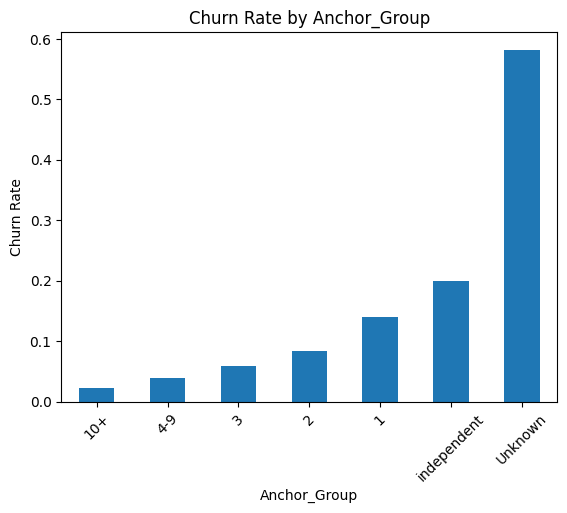

In [82]:
import matplotlib.pyplot as plt

churn = df.groupby('Anchor_Group')['target'].mean().sort_values()

plt.figure()
churn.plot(kind='bar')
plt.title("Churn Rate by Anchor_Group")
plt.ylabel("Churn Rate")
plt.xlabel("Anchor_Group")
plt.xticks(rotation=45)
plt.show()

In [83]:
# df = df.drop(columns=['Current_Anchorings'])

In [84]:
# days since reg vs tenure score  both are same in general

df = df.drop(columns=['Tenure_Scores'])


In [85]:
if 'days_since_registration' in df.columns:
    print("Column exists")
else:
    print("Column not found")

Column not found


In [86]:
print(len(df.columns))

46


In [87]:
extra_in_df = set(df.columns) - set(df_copy.columns)
# print("Extra in df:", extra_in_df)

print(set(df.columns) - set(extra_in_df))
print(len(set(df.columns) - set(extra_in_df)))

{'Discount_or_Waiver_Requested_renewal', 'Payment_Timeframe', 'Sustainability_Score', 'Connection_Group', 'Current_Anchorings', 'Tenure_Years', 'Current_World_Pay_Token', 'Status_Scores', 'Auto_Renewal_Score', 'Total_Renewal_Score_New', 'Current_Auto_Renewal_Flag', 'Agent_Renewal_Pitch_Category_renewal', 'Total_Net_Paid', 'Current_Anchor_List', 'Last_Years_Price', 'Customer_Renewal_Response_Category_renewal', 'Proforma_Approved_Lists', 'Tenure_Group', 'Discount_Amount', 'Proforma_World_Pay_Token', 'Renewal_Score_At_Release', 'Agent_Response_Category_renewal', 'Agent_Renewal_Initiation_renewal', 'Co_Ref', 'Proforma_Auto_Renewal', 'Call_Reschedule_Request_renewal', 'Other_Complaint_renewal', 'Band', 'Explicit_Competitor_Mention_renewal', 'Price_Switching_Mentioned_renewal', 'Anchoring_Score', 'Serious_Complaint_renewal', 'Competitor_Value_Comparison_renewal', 'Anchor_Group', 'Renewal_Impact_Due_to_Price_Increase_renewal'}
35


In [88]:
ct = pd.crosstab(
    df['Proforma_World_Pay_Token'],
    df['target'],
    normalize='index'
) * 100

print(ct.round(2))

target                        0      1
Proforma_World_Pay_Token              
False                     88.96  11.04
True                      89.67  10.33


In [89]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Proforma_World_Pay_Token'], df['target'])

chi2, p, _, _ = chi2_contingency(table)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 11.775882975055353
p-value: 0.0006000304409455499


In [90]:
diff = df.groupby('Proforma_World_Pay_Token')['target'].mean().diff().iloc[-1]
print("Difference:", diff)

Difference: -0.007064701369629195


In [91]:
# Metric	Result	Decision
# p-value	Significant	⚠️ misleading
# Difference	~0.7%	❌ weak
# Signal strength	Very low	❌ useless

In [92]:
df = df.drop(columns=['Proforma_World_Pay_Token'])

In [93]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Proforma_Auto_Renewal'], df['target'])

chi2, p, _, _ = chi2_contingency(table)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 198.99142210562235
p-value: 3.4668007734218895e-45


In [94]:
diff = df.groupby('Proforma_Auto_Renewal')['target'].mean().diff().iloc[-1]
print("Difference:", diff)

# Kepping it

Difference: -0.11768269995401308


In [95]:
print(len(df.columns))
print(df.columns)

45
Index(['Co_Ref', 'Discount_Amount', 'Sustainability_Score',
       'Total_Renewal_Score_New', 'Last_Years_Price', 'Auto_Renewal_Score',
       'Status_Scores', 'Anchoring_Score', 'Proforma_Auto_Renewal',
       'Current_Anchorings', 'Current_Anchor_List', 'Payment_Timeframe',
       'Current_Auto_Renewal_Flag', 'Current_World_Pay_Token',
       'Renewal_Score_At_Release', 'Proforma_Approved_Lists', 'Tenure_Years',
       'Band', 'Total_Net_Paid', 'Connection_Group', 'Tenure_Group',
       'Anchor_Group', 'Agent_Renewal_Pitch_Category_renewal',
       'Customer_Renewal_Response_Category_renewal',
       'Agent_Response_Category_renewal', 'Serious_Complaint_renewal',
       'Other_Complaint_renewal',
       'Renewal_Impact_Due_to_Price_Increase_renewal',
       'Discount_or_Waiver_Requested_renewal',
       'Call_Reschedule_Request_renewal', 'Agent_Renewal_Initiation_renewal',
       'Explicit_Competitor_Mention_renewal',
       'Price_Switching_Mentioned_renewal',
       'Competitor_

In [96]:
df = df.drop(columns=['Total_Renewal_Score_New'])

In [97]:
print(df['Proforma_Approved_Lists'].value_counts())
print(df['Current_Anchorings'].value_counts())

df = df.drop(columns=['Proforma_Approved_Lists'])



Proforma_Approved_Lists
1.0      35435
0.0      23118
2.0      18167
3.0       9830
4.0       6355
         ...  
162.0        1
163.0        1
128.0        1
134.0        1
114.0        1
Name: count, Length: 133, dtype: int64
Current_Anchorings
1      33149
0      23963
2      19101
3      10977
4       6613
       ...  
133        3
150        3
87         3
69         2
89         1
Name: count, Length: 107, dtype: int64


In [98]:
len(df.columns)

43

In [99]:
print(df.columns)

Index(['Co_Ref', 'Discount_Amount', 'Sustainability_Score', 'Last_Years_Price',
       'Auto_Renewal_Score', 'Status_Scores', 'Anchoring_Score',
       'Proforma_Auto_Renewal', 'Current_Anchorings', 'Current_Anchor_List',
       'Payment_Timeframe', 'Current_Auto_Renewal_Flag',
       'Current_World_Pay_Token', 'Renewal_Score_At_Release', 'Tenure_Years',
       'Band', 'Total_Net_Paid', 'Connection_Group', 'Tenure_Group',
       'Anchor_Group', 'Agent_Renewal_Pitch_Category_renewal',
       'Customer_Renewal_Response_Category_renewal',
       'Agent_Response_Category_renewal', 'Serious_Complaint_renewal',
       'Other_Complaint_renewal',
       'Renewal_Impact_Due_to_Price_Increase_renewal',
       'Discount_or_Waiver_Requested_renewal',
       'Call_Reschedule_Request_renewal', 'Agent_Renewal_Initiation_renewal',
       'Explicit_Competitor_Mention_renewal',
       'Price_Switching_Mentioned_renewal',
       'Competitor_Value_Comparison_renewal', 'Explicit_Switching_Intent_flag',
   

In [100]:
df['Agent_Renewal_Pitch_Category_renewal'].isnull().sum()

df.drop(columns=['Agent_Renewal_Pitch_Category_renewal'], inplace=True)

In [101]:
len(df)

113894

In [102]:
df['Call_Reschedule_Request_renewal'].value_counts()

ct = pd.crosstab(
    df['Call_Reschedule_Request_renewal'],
    df['target'],
    normalize='index'
) * 100

print(ct.round(2))

target                               0      1
Call_Reschedule_Request_renewal              
No                               90.61   9.39
Yes                              86.39  13.61


In [103]:
df['Agent_Renewal_Initiation_renewal'].value_counts()
ct = pd.crosstab(
    df['Agent_Renewal_Initiation_renewal'],
    df['target'],
    normalize='index'
) * 100

print(ct.round(2))

target                                0      1
Agent_Renewal_Initiation_renewal              
No                                89.75  10.25
Yes                               90.88   9.12


In [104]:
# Metric	Value	Meaning
# Difference	~1.1%	❌ Very weak


df = df.drop(columns=['Agent_Renewal_Initiation_renewal'])

In [105]:
# Still Reduce
# https://chatgpt.com/s/t_69dd0783f9f48191b440da3615b3d47a

In [106]:
print(df['Other_Complaint_renewal'].value_counts())

ct = pd.crosstab(
    df['Other_Complaint_renewal'],
    df['target'],
    normalize='index'
) * 100

print(ct.round(2))

Other_Complaint_renewal
No     13521
Yes     2648
Name: count, dtype: int64
target                       0      1
Other_Complaint_renewal              
No                       91.81   8.19
Yes                      84.55  15.45


In [107]:
# Group	Churn
# No complaint	8.19%
# Yes complaint	15.45%

# 👉 Difference = 7.26%

# No group:
# 13617 × 8.19% ≈ 1115 churners
# Yes group:
# 2681 × 15.45% ≈ 414 churners


In [108]:
print(df.columns)
print(len(df.columns))

Index(['Co_Ref', 'Discount_Amount', 'Sustainability_Score', 'Last_Years_Price',
       'Auto_Renewal_Score', 'Status_Scores', 'Anchoring_Score',
       'Proforma_Auto_Renewal', 'Current_Anchorings', 'Current_Anchor_List',
       'Payment_Timeframe', 'Current_Auto_Renewal_Flag',
       'Current_World_Pay_Token', 'Renewal_Score_At_Release', 'Tenure_Years',
       'Band', 'Total_Net_Paid', 'Connection_Group', 'Tenure_Group',
       'Anchor_Group', 'Customer_Renewal_Response_Category_renewal',
       'Agent_Response_Category_renewal', 'Serious_Complaint_renewal',
       'Other_Complaint_renewal',
       'Renewal_Impact_Due_to_Price_Increase_renewal',
       'Discount_or_Waiver_Requested_renewal',
       'Call_Reschedule_Request_renewal',
       'Explicit_Competitor_Mention_renewal',
       'Price_Switching_Mentioned_renewal',
       'Competitor_Value_Comparison_renewal', 'Explicit_Switching_Intent_flag',
       'Discount_Offered_flag', 'Customer_Response_flag', 'cancel_flag',
       'targe

# Cleaning and Check 

In [109]:
for col in df.columns:
    print(col, df[col].isnull().sum())

Co_Ref 0
Discount_Amount 0
Sustainability_Score 0
Last_Years_Price 8817
Auto_Renewal_Score 0
Status_Scores 0
Anchoring_Score 0
Proforma_Auto_Renewal 18048
Current_Anchorings 0
Current_Anchor_List 23963
Payment_Timeframe 12668
Current_Auto_Renewal_Flag 0
Current_World_Pay_Token 0
Renewal_Score_At_Release 122
Tenure_Years 975
Band 0
Total_Net_Paid 12668
Connection_Group 0
Tenure_Group 0
Anchor_Group 0
Customer_Renewal_Response_Category_renewal 100533
Agent_Response_Category_renewal 100608
Serious_Complaint_renewal 97725
Other_Complaint_renewal 97725
Renewal_Impact_Due_to_Price_Increase_renewal 96989
Discount_or_Waiver_Requested_renewal 96989
Call_Reschedule_Request_renewal 96928
Explicit_Competitor_Mention_renewal 96903
Price_Switching_Mentioned_renewal 96904
Competitor_Value_Comparison_renewal 82298
Explicit_Switching_Intent_flag 0
Discount_Offered_flag 0
Customer_Response_flag 0
cancel_flag 0
target 0
Call_attend_status_renewal 0
competitor_mentioned_flag 0
topic_customer_flag 0
stage_

In [110]:
df['Customer_Renewal_Response_Category_renewal'].value_counts()

Customer_Renewal_Response_Category_renewal
Agreement                                                3340
Communication                                            2026
Auto / Automatic                                         1479
Confusion / Uncertainty / Hesitation                     1244
Payments and Billings / Invoice                          1207
Not Mentioned                                             870
Accreditation and Certification                           803
Price and Cost                                            735
Cancellation / Termination / Non-Renewal / Withdrawal     549
Quality / Value / Satisfaction of service                 242
Assessment                                                170
Financial Hardship / Struggles                            167
Package                                                   128
Discount and Offer                                        120
Audit                                                      70
Benefits                   

In [111]:
pd.crosstab(
    df['Customer_Renewal_Response_Category_renewal'],
    df['target'],
    normalize='index'
) * 100

target,0,1
Customer_Renewal_Response_Category_renewal,,
Accreditation and Certification,83.935243,16.064757
Agreement,97.215569,2.784431
Assessment,97.058824,2.941176
Audit,91.428571,8.571429
Auto / Automatic,96.484111,3.515889
Benefits,70.312500,29.687500
Cancellation / Termination / Non-Renewal / Withdrawal,28.779599,71.220401
Communication,93.780849,6.219151
Confusion / Uncertainty / Hesitation,87.781350,12.218650


In [112]:
def map_risk_improved(x):
    if x in ['Cancellation / Termination / Non-Renewal / Withdrawal',
             'Financial Hardship / Struggles']:
        return 'High Risk'
    
    elif x in ['Confusion / Uncertainty / Hesitation',
               'Price and Cost',
               'Quality / Value / Satisfaction of service']:
        return 'Medium Risk'
    
    elif x in ['Agreement', 'Auto / Automatic',
               'Payments and Billings / Invoice']:
        return 'Low Risk'
    
    elif x == 'Missing':
        return 'Missing'
    
    else:
        return 'Neutral'   # instead of dumping into "Other"

df['Customer_Response_Risk'] = df['Customer_Renewal_Response_Category_renewal'].apply(map_risk_improved)

In [113]:
df  = df.drop(columns=['Customer_Renewal_Response_Category_renewal'])


In [114]:
pd.crosstab(df['Customer_Response_Risk'], df['target'])

target,0,1
Customer_Response_Risk,,
High Risk,253,463
Low Risk,5857,169
Medium Risk,1944,277
Neutral,93172,11759


In [115]:
print(df['Customer_Response_Risk'].isnull().sum())

0


In [116]:
def analyze_column(df, col):
    print(f"\n===== {col} =====")
    
    # Null stats
    nulls = df[col].isnull().sum()
    total = len(df)
    print(f"Null %: {round((nulls/total)*100,2)}%")
    
    # Value counts
    print("\nValue Counts:")
    print(df[col].value_counts(dropna=False).head(10))
    
    # Crosstab
    print("\nCrosstab (%):")
    print(pd.crosstab(df[col], df['target'], normalize='index') * 100)
high_null_cols = [
    # 'Agent_Response_Category_renewal',
    'Serious_Complaint_renewal',
    # 'Other_Complaint_renewal',
    'Renewal_Impact_Due_to_Price_Increase_renewal',
    # 'Discount_or_Waiver_Requested_renewal',
    'Call_Reschedule_Request_renewal',
    # 'Explicit_Competitor_Mention_renewal',
    # 'Price_Switching_Mentioned_renewal',
    'Competitor_Value_Comparison_renewal'
]

for col in high_null_cols:
    analyze_column(df , col)


===== Serious_Complaint_renewal =====
Null %: 85.8%

Value Counts:
Serious_Complaint_renewal
NaN    97725
No     16105
Yes       64
Name: count, dtype: int64

Crosstab (%):
target                             0          1
Serious_Complaint_renewal                      
No                         90.729587   9.270413
Yes                        62.500000  37.500000

===== Renewal_Impact_Due_to_Price_Increase_renewal =====
Null %: 85.16%

Value Counts:
Renewal_Impact_Due_to_Price_Increase_renewal
NaN                                                                                                                              96989
No                                                                                                                               16322
Yes                                                                                                                                577
[Yes/No]                                                                                        

In [117]:
df = df.drop(columns=['Other_Complaint_renewal'])

In [118]:
df['agent_complaint_flag'] = df['Agent_Response_Category_renewal'].isin([
    'Complaints',
    'Customer Service / Support'
]).astype(int)

In [119]:
df = df.drop(columns = ['Agent_Response_Category_renewal'])

In [120]:
df['Explicit_Competitor_Mention_renewal'] = df['Explicit_Competitor_Mention_renewal'].fillna('No')
df['Explicit_Competitor_Mention_renewal'] = \
    df['Explicit_Competitor_Mention_renewal'].apply(lambda x: 1 if x == 'Yes' else 0)

In [121]:
df['Price_Switching_Mentioned_renewal'] = df['Price_Switching_Mentioned_renewal'].fillna('No')
df['Price_Switching_Mentioned_renewal'] = \
    df['Price_Switching_Mentioned_renewal'].apply(lambda x: 1 if 'Yes' in str(x) else 0)

In [122]:
# Serious Complaint
df['Serious_Complaint_renewal'] = df['Serious_Complaint_renewal'].fillna('No').map({'No': 0, 'Yes': 1})

# Price Impact
df['Renewal_Impact_Due_to_Price_Increase_renewal'] = \
    df['Renewal_Impact_Due_to_Price_Increase_renewal'].fillna('No') \
    .apply(lambda x: 1 if 'Yes' in str(x) else 0)

# Call Reschedule
df['Call_Reschedule_Request_renewal'] = \
    df['Call_Reschedule_Request_renewal'].fillna('No').map({'No': 0, 'Yes': 1})

# Competitor Value
df['Competitor_Value_Comparison_renewal'] = \
    df['Competitor_Value_Comparison_renewal'].fillna('unknown')

In [123]:
# too sparse
# This feature is:

# ❌ Too sparse
# ❌ Weak separation
# ❌ Noisy text variations

# 👉 Raw column = NOT useful
df.drop(columns=['Discount_or_Waiver_Requested_renewal'], inplace=True)
# df.drop(columns=['Last_Years_Price '], inplace=True)


In [124]:
for col in df.columns:
    print(col , df[col].isnull().sum())

Co_Ref 0
Discount_Amount 0
Sustainability_Score 0
Last_Years_Price 8817
Auto_Renewal_Score 0
Status_Scores 0
Anchoring_Score 0
Proforma_Auto_Renewal 18048
Current_Anchorings 0
Current_Anchor_List 23963
Payment_Timeframe 12668
Current_Auto_Renewal_Flag 0
Current_World_Pay_Token 0
Renewal_Score_At_Release 122
Tenure_Years 975
Band 0
Total_Net_Paid 12668
Connection_Group 0
Tenure_Group 0
Anchor_Group 0
Serious_Complaint_renewal 0
Renewal_Impact_Due_to_Price_Increase_renewal 0
Call_Reschedule_Request_renewal 0
Explicit_Competitor_Mention_renewal 0
Price_Switching_Mentioned_renewal 0
Competitor_Value_Comparison_renewal 0
Explicit_Switching_Intent_flag 0
Discount_Offered_flag 0
Customer_Response_flag 0
cancel_flag 0
target 0
Call_attend_status_renewal 0
competitor_mentioned_flag 0
topic_customer_flag 0
stage_high_risk_flag 0
stage_low_risk_flag 0
pct_inc_total_net_paid 52375
Customer_Response_Risk 0
agent_complaint_flag 0


In [125]:
df['Current_Anchor_List'] = df['Current_Anchor_List'].fillna('None')

In [126]:
df['Proforma_Auto_Renewal'].value_counts()

Proforma_Auto_Renewal
True     94437
False     1409
Name: count, dtype: int64

In [127]:
df['Proforma_Auto_Renewal'] = (
    df['Proforma_Auto_Renewal']
    .fillna('')                 # handle NaN
    .astype(str)                # ensure string
    .str.lower()                # vectorized (SAFE)
    .str.contains('yes')        # check condition
    .astype(int)                # convert True/False → 1/0
)

In [128]:
df['Proforma_Auto_Renewal'].isnull().sum()

0

In [129]:
df = df.drop(columns='Last_Years_Price')

In [130]:
# no need pct_increse while already have total_net_paid
df = df.drop(columns=['pct_inc_total_net_paid'])

In [131]:
df.drop(columns=['pct_inc_total_net_paid'], inplace=True, errors='ignore')

In [132]:
df['Payment_Timeframe'] = df['Payment_Timeframe'].fillna(
    df.groupby('Co_Ref')['Payment_Timeframe'].transform('median')
)
df['Payment_Timeframe'] = df['Payment_Timeframe'].fillna(
    df['Payment_Timeframe'].median()
)

In [133]:
# 2. Group-level (Co_Ref) median
group_median = df.groupby('Co_Ref')['Total_Net_Paid'].transform('median')

df['Total_Net_Paid'] = df['Total_Net_Paid'].fillna(group_median)

# 3. Fallback → global median
df['Total_Net_Paid'] = df['Total_Net_Paid'].fillna(df['Total_Net_Paid'].median())



In [134]:
df['Renewal_Score_At_Release'] = df['Renewal_Score_At_Release'].fillna(
    df.groupby('Co_Ref')['Renewal_Score_At_Release'].transform('median')
)

# fallback → global median
df['Renewal_Score_At_Release'] = df['Renewal_Score_At_Release'].fillna(
    df['Renewal_Score_At_Release'].median()
)

In [135]:
# Co_Ref median
df['Tenure_Years'] = df['Tenure_Years'].fillna(
    df.groupby('Co_Ref')['Tenure_Years'].transform('median')
)

# fallback → global median
df['Tenure_Years'] = df['Tenure_Years'].fillna(
    df['Tenure_Years'].median()
)

In [136]:
for col in df.columns:
    print(col , df[col].isnull().sum())

Co_Ref 0
Discount_Amount 0
Sustainability_Score 0
Auto_Renewal_Score 0
Status_Scores 0
Anchoring_Score 0
Proforma_Auto_Renewal 0
Current_Anchorings 0
Current_Anchor_List 0
Payment_Timeframe 0
Current_Auto_Renewal_Flag 0
Current_World_Pay_Token 0
Renewal_Score_At_Release 0
Tenure_Years 0
Band 0
Total_Net_Paid 0
Connection_Group 0
Tenure_Group 0
Anchor_Group 0
Serious_Complaint_renewal 0
Renewal_Impact_Due_to_Price_Increase_renewal 0
Call_Reschedule_Request_renewal 0
Explicit_Competitor_Mention_renewal 0
Price_Switching_Mentioned_renewal 0
Competitor_Value_Comparison_renewal 0
Explicit_Switching_Intent_flag 0
Discount_Offered_flag 0
Customer_Response_flag 0
cancel_flag 0
target 0
Call_attend_status_renewal 0
competitor_mentioned_flag 0
topic_customer_flag 0
stage_high_risk_flag 0
stage_low_risk_flag 0
Customer_Response_Risk 0
agent_complaint_flag 0


In [137]:
df.drop(columns=['Co_Ref'], inplace=True)

In [138]:
print(len(df.columns))

36


In [139]:
for col in df.columns:
    print(col , "---" , df[col].dtype , df[col].value_counts)

Discount_Amount --- str <bound method IndexOpsMixin.value_counts of 0              0
1              0
2              0
3              0
4              0
           ...  
122077         0
122078         0
122079         0
122080         0
122081    20.00%
Name: Discount_Amount, Length: 113894, dtype: str>
Sustainability_Score --- float64 <bound method IndexOpsMixin.value_counts of 0         8.0
1         8.0
2         9.5
3         9.5
4         9.5
         ... 
122077    9.0
122078    9.0
122079    9.0
122080    9.5
122081    9.5
Name: Sustainability_Score, Length: 113894, dtype: float64>
Auto_Renewal_Score --- int64 <bound method IndexOpsMixin.value_counts of 0         8
1         8
2         9
3         9
4         9
         ..
122077    9
122078    9
122079    9
122080    8
122081    8
Name: Auto_Renewal_Score, Length: 113894, dtype: int64>
Status_Scores --- int64 <bound method IndexOpsMixin.value_counts of 0         0
1         0
2         9
3         9
4         9
         ..
12

# Ready dataset finetune

In [140]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# ================================
# STEP 1: FIX SPECIAL COLUMNS
# ================================

# 🔥 Fix Discount_Amount (object → numeric)
df['Discount_Amount'] = (
    df['Discount_Amount']
    .astype(str)
    .str.replace('%', '')
)

df['Discount_Amount'] = pd.to_numeric(df['Discount_Amount'], errors='coerce')

# ================================
# STEP 2: FIX BINARY STRING COLS
# ================================

binary_map = {'y': 1, 'n': 0, 'yes': 1, 'no': 0}

binary_cols = [
    'Current_Auto_Renewal_Flag',
    'Current_World_Pay_Token'
]

for col in binary_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.lower()
        .map(binary_map)
        .fillna(0)
        .astype(int)
    )

# ================================
# STEP 3: DROP HIGH CARDINALITY
# ================================

# ❌ Drop anchor list (too many unique values)
df.drop(columns=['Current_Anchor_List'], inplace=True, errors='ignore')

# ================================
# STEP 4: TYPE CASTING
# ================================

# Convert remaining object → category
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')

# ================================
# STEP 5: SPLIT TYPES
# ================================

num_cols = df.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()
cat_cols = df.select_dtypes(include=['category']).columns.tolist()

# Remove target from encoding
if 'target' in cat_cols:
    cat_cols.remove('target')

print("Numeric:", len(num_cols))
print("Categorical:", cat_cols)

# ================================
# STEP 6: ENCODING
# ================================

for col in cat_cols:
    
    unique_vals = df[col].nunique()
    
    if unique_vals <= 20:
        # One-hot encode
        df = pd.get_dummies(df, columns=[col], drop_first=True)
        
    else:
        # Label encode
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

# ================================
# STEP 7: FINAL CHECK
# ================================

print("\nRemaining categorical columns:")
print(df.select_dtypes(include='object').columns)

print("\nDataset shape:", df.shape)

Numeric: 29
Categorical: ['Band', 'Connection_Group', 'Tenure_Group', 'Anchor_Group', 'Competitor_Value_Comparison_renewal', 'Customer_Response_Risk']

Remaining categorical columns:
Index([], dtype='str')

Dataset shape: (113894, 65)


C:\Users\Asus\AppData\Local\Temp\ipykernel_22448\888846563.py:50: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [141]:
corr = df.corr().abs()
high_corr = (corr > 0.9).sum().sort_values(ascending=False)
high_corr.head(10)

competitor_mentioned_flag                            3
Competitor_Value_Comparison_renewal_unknown          3
Competitor_Value_Comparison_renewal_not discussed    3
Connection_Group_10+                                 2
Connection_Group_2                                   2
Connection_Group_3                                   2
Connection_Group_4-9                                 2
Connection_Group_Unknown                             2
Connection_Group_independent                         2
Anchor_Group_10+                                     2
dtype: int64

In [142]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y == 0).sum() / (y == 1).sum()
)
# model = XGBClassifier(
#     n_estimators=500,
#     max_depth=4,
#     learning_rate=0.03
# )

model.fit(X_train, y_train)
print(X_test , X_train)

        Discount_Amount  Sustainability_Score  Auto_Renewal_Score  \
106226              0.0                   9.0                   8   
24937              20.0                   8.0                   9   
62818               0.0                   8.0                   9   
47853               0.0                   8.0                   9   
63715               0.0                   9.5                   9   
...                 ...                   ...                 ...   
9048                0.0                   9.5                   8   
56425               0.0                   9.5                   9   
55146               0.0                   8.0                   8   
22755               0.0                   9.5                   9   
115131              0.0                   8.0                   9   

        Status_Scores  Anchoring_Score  Proforma_Auto_Renewal  \
106226              9              9.5                      0   
24937               9              7.5   

In [143]:
# from sklearn.metrics import classification_report, roc_auc_score

# y_pred = model.predict(X_test)
# y_prob = model.predict_proba(X_test)[:, 1]

# print(classification_report(y_test, y_pred))
# print("ROC AUC:", roc_auc_score(y_test, y_prob))

from sklearn.metrics import classification_report, roc_auc_score

# Probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# 🔥 Custom threshold (change this to improve precision)
threshold = 0.05

# Predictions using custom threshold
y_pred = (y_prob > threshold).astype(int)

# Evaluation
print(f"Threshold used: {threshold}")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Threshold used: 0.05
              precision    recall  f1-score   support

           0       1.00      0.80      0.89     20245
           1       0.38      0.99      0.55      2534

    accuracy                           0.82     22779
   macro avg       0.69      0.89      0.72     22779
weighted avg       0.93      0.82      0.85     22779

ROC AUC: 0.988969330515705


In [144]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Compute F1 for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

# Get best threshold
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best Threshold (F1):", best_threshold)
print("Best F1 Score:", f1_scores[best_idx])

Best Threshold (F1): 0.7880426
Best F1 Score: 0.8648122883291544


In [145]:
sample_non_churn_full = {
 'Discount_Amount': 0.0,
 'Sustainability_Score': 9.5,
 'Auto_Renewal_Score': 9,
 'Status_Scores': 9,
 'Anchoring_Score': 9.0,
 'Proforma_Auto_Renewal': 0,
 'Current_Anchorings': 2,
 'Payment_Timeframe': 0.0,
 'Current_Auto_Renewal_Flag': 1,
 'Current_World_Pay_Token': 1,
 'Renewal_Score_At_Release': 27.0,
 'Tenure_Years': 5,
 'Total_Net_Paid': 700,
 'Serious_Complaint_renewal': 0,
 'Renewal_Impact_Due_to_Price_Increase_renewal': 0,
 'Call_Reschedule_Request_renewal': 0,
 'Explicit_Competitor_Mention_renewal': 0,
 'Price_Switching_Mentioned_renewal': 0,
 'Explicit_Switching_Intent_flag': 0,
 'Discount_Offered_flag': 0,
 'Customer_Response_flag': 0,
 'cancel_flag': 0,
 'Call_attend_status_renewal': 1,
 'competitor_mentioned_flag': 0,
 'topic_customer_flag': 0,
 'stage_high_risk_flag': 0,
 'stage_low_risk_flag': 1,
 'agent_complaint_flag': 0,

 # Band
 'Band_Band B': 0, 'Band_Band C1': 0, 'Band_Band C2': 0, 'Band_Band D': 1,
 'Band_Band E': 0, 'Band_Band F': 0, 'Band_Band F1': 0, 'Band_Band F2': 0,
 'Band_Band G': 0, 'Band_Band H': 0, 'Band_Band I': 0, 'Band_Band J': 0,
 'Band_Group': 0, 'Band_Unknown': 0,

 # Connection
 'Connection_Group_10+': 0, 'Connection_Group_2': 0, 'Connection_Group_3': 1,
 'Connection_Group_4-9': 0, 'Connection_Group_Unknown': 0,
 'Connection_Group_independent': 0,

 # Tenure
 'Tenure_Group_2': 0, 'Tenure_Group_3': 0,
 'Tenure_Group_4+': 1, 'Tenure_Group_Unknown': 0,

 # Anchor
 'Anchor_Group_10+': 0, 'Anchor_Group_2': 0, 'Anchor_Group_3': 1,
 'Anchor_Group_4-9': 0, 'Anchor_Group_Unknown': 0,
 'Anchor_Group_independent': 0,

 # Competitor
 'Competitor_Value_Comparison_renewal_not discussed': 0,
 'Competitor_Value_Comparison_renewal_similar value': 0,
 'Competitor_Value_Comparison_renewal_unknown': 1,

 # Customer risk
 'Customer_Response_Risk_Low Risk': 1,
 'Customer_Response_Risk_Medium Risk': 0,
 'Customer_Response_Risk_Neutral': 0
}

sample_churn_full = {
 'Discount_Amount': 20.0,
 'Sustainability_Score': 8.0,
 'Auto_Renewal_Score': 8,
 'Status_Scores': 0,
 'Anchoring_Score': 7.5,
 'Proforma_Auto_Renewal': 0,
 'Current_Anchorings': 0,
 'Payment_Timeframe': 3.5,
 'Current_Auto_Renewal_Flag': 1,
 'Current_World_Pay_Token': 0,
 'Renewal_Score_At_Release': 24.0,
 'Tenure_Years': 1,
 'Total_Net_Paid': 400,
 'Serious_Complaint_renewal': 1,
 'Renewal_Impact_Due_to_Price_Increase_renewal': 1,
 'Call_Reschedule_Request_renewal': 1,
 'Explicit_Competitor_Mention_renewal': 1,
 'Price_Switching_Mentioned_renewal': 1,
 'Explicit_Switching_Intent_flag': 1,
 'Discount_Offered_flag': 1,
 'Customer_Response_flag': 1,
 'cancel_flag': 0,
 'Call_attend_status_renewal': 1,
 'competitor_mentioned_flag': 1,
 'topic_customer_flag': 1,
 'stage_high_risk_flag': 1,
 'stage_low_risk_flag': 0,
 'agent_complaint_flag': 1,

 # Band
 'Band_Band B': 0, 'Band_Band C1': 1, 'Band_Band C2': 0, 'Band_Band D': 0,
 'Band_Band E': 0, 'Band_Band F': 0, 'Band_Band F1': 0, 'Band_Band F2': 0,
 'Band_Band G': 0, 'Band_Band H': 0, 'Band_Band I': 0, 'Band_Band J': 0,
 'Band_Group': 0, 'Band_Unknown': 0,

 # Connection
 'Connection_Group_10+': 0, 'Connection_Group_2': 1, 'Connection_Group_3': 0,
 'Connection_Group_4-9': 0, 'Connection_Group_Unknown': 0,
 'Connection_Group_independent': 0,

 # Tenure
 'Tenure_Group_2': 1, 'Tenure_Group_3': 0,
 'Tenure_Group_4+': 0, 'Tenure_Group_Unknown': 0,

 # Anchor
 'Anchor_Group_10+': 0, 'Anchor_Group_2': 1, 'Anchor_Group_3': 0,
 'Anchor_Group_4-9': 0, 'Anchor_Group_Unknown': 0,
 'Anchor_Group_independent': 0,

 # Competitor
 'Competitor_Value_Comparison_renewal_not discussed': 0,
 'Competitor_Value_Comparison_renewal_similar value': 1,
 'Competitor_Value_Comparison_renewal_unknown': 0,

 # Customer risk
 'Customer_Response_Risk_Low Risk': 0,
 'Customer_Response_Risk_Medium Risk': 1,
 'Customer_Response_Risk_Neutral': 0
}
sample_churn_fixed = sample_churn_full.copy()

# Make it clearly churn-like
sample_churn_fixed.update({
    'Serious_Complaint_renewal': 1,
    'Renewal_Impact_Due_to_Price_Increase_renewal': 1,
    'Price_Switching_Mentioned_renewal': 1,
    'Explicit_Switching_Intent_flag': 1,
    'stage_high_risk_flag': 1,
    
    # 🔥 IMPORTANT
    'Customer_Response_Risk_Low Risk': 0,
    'Customer_Response_Risk_Medium Risk': 0,
    'Customer_Response_Risk_Neutral': 0,
    # (implicitly High Risk pattern)
})


sample_churn_strong = {
 'Discount_Amount': 50.0,
 'Sustainability_Score': 6.0,   # ↓ low
 'Auto_Renewal_Score': 5,       # ↓ low
 'Status_Scores': 0,
 'Anchoring_Score': 6.5,

 'Proforma_Auto_Renewal': 0,
 'Current_Anchorings': 0,
 'Payment_Timeframe': 5.0,

 # ❗ REMOVE retention
 'Current_Auto_Renewal_Flag': 0,
 'Current_World_Pay_Token': 0,

 'Renewal_Score_At_Release': 20.0,
 'Tenure_Years': 1,
 'Total_Net_Paid': 200,

 # 🔥 strong churn signals
 'Serious_Complaint_renewal': 1,
 'Renewal_Impact_Due_to_Price_Increase_renewal': 1,
 'Call_Reschedule_Request_renewal': 1,
 'Explicit_Competitor_Mention_renewal': 1,
 'Price_Switching_Mentioned_renewal': 1,
 'Explicit_Switching_Intent_flag': 1,

 'Discount_Offered_flag': 1,
 'Customer_Response_flag': 1,

 'cancel_flag': 0,
 'Call_attend_status_renewal': 0,

 'competitor_mentioned_flag': 1,
 'topic_customer_flag': 1,

 'stage_high_risk_flag': 1,
 'stage_low_risk_flag': 0,

 'agent_complaint_flag': 1,

 # categories
 'Band_Band B': 0, 'Band_Band C1': 1, 'Band_Band C2': 0, 'Band_Band D': 0,
 'Band_Band E': 0, 'Band_Band F': 0, 'Band_Band F1': 0, 'Band_Band F2': 0,
 'Band_Band G': 0, 'Band_Band H': 0, 'Band_Band I': 0, 'Band_Band J': 0,
 'Band_Group': 0, 'Band_Unknown': 0,

 'Connection_Group_10+': 0, 'Connection_Group_2': 1, 'Connection_Group_3': 0,
 'Connection_Group_4-9': 0, 'Connection_Group_Unknown': 0,
 'Connection_Group_independent': 0,

 'Tenure_Group_2': 1, 'Tenure_Group_3': 0,
 'Tenure_Group_4+': 0, 'Tenure_Group_Unknown': 0,

 'Anchor_Group_10+': 0, 'Anchor_Group_2': 1, 'Anchor_Group_3': 0,
 'Anchor_Group_4-9': 0, 'Anchor_Group_Unknown': 0,
 'Anchor_Group_independent': 0,

 'Competitor_Value_Comparison_renewal_not discussed': 0,
 'Competitor_Value_Comparison_renewal_similar value': 1,
 'Competitor_Value_Comparison_renewal_unknown': 0,

 'Customer_Response_Risk_Low Risk': 0,
 'Customer_Response_Risk_Medium Risk': 1,
 'Customer_Response_Risk_Neutral': 0
}

test_df = pd.DataFrame([sample_non_churn_full, sample_churn_fixed , sample_churn_strong])

preds = model.predict(test_df)
probs = model.predict_proba(test_df)[:, 1]

test_df['prediction'] = preds
test_df['probability'] = probs

print(test_df[['prediction', 'probability']])

   prediction  probability
0           0     0.000850
1           0     0.008891
2           0     0.007902


In [146]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(20)

print(top_features)

Status_Scores                0.422602
Sustainability_Score         0.070414
Auto_Renewal_Score           0.052061
Connection_Group_Unknown     0.027556
Current_Auto_Renewal_Flag    0.026311
Current_World_Pay_Token      0.025148
cancel_flag                  0.023553
Tenure_Years                 0.021317
Discount_Amount              0.019887
stage_high_risk_flag         0.018596
Band_Band F                  0.018250
Total_Net_Paid               0.018223
Band_Band B                  0.013919
Band_Band C1                 0.010258
Payment_Timeframe            0.010226
Tenure_Group_4+              0.009158
Anchor_Group_Unknown         0.009118
Renewal_Score_At_Release     0.009014
Anchor_Group_independent     0.008960
Tenure_Group_3               0.008916
dtype: float32


# ====================================================================

C:\Users\Asus\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


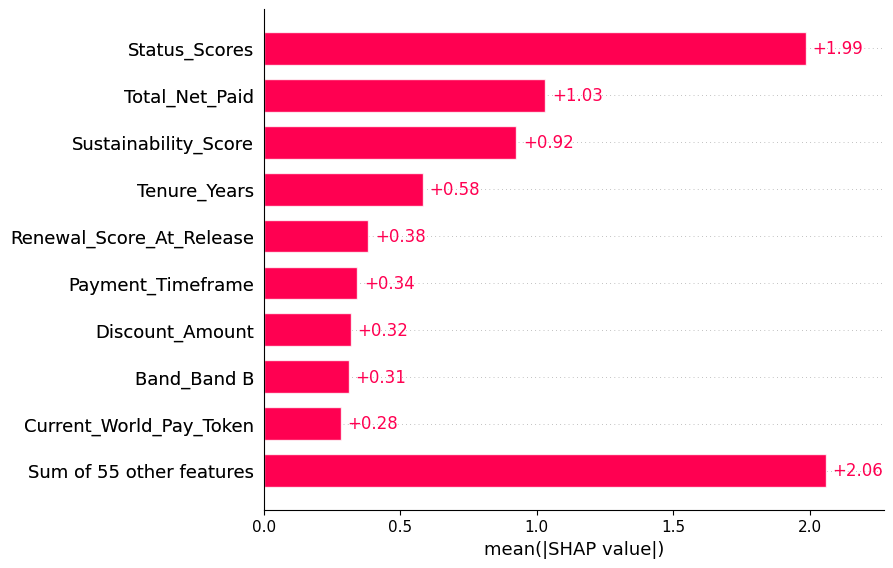

In [147]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)

# tune

In [148]:
# model = XGBClassifier(
#     n_estimators=500,
#     max_depth=4,
#     learning_rate=0.03
# )

In [149]:
# low_importance = importance[importance < 0.001].index
# df.drop(columns=low_importance, inplace=True)